# Figure: syllable correlates of engagement, and trial-mode entropy along LD1

Panels only — the analyses behind them live in `GLM-HMM/transition_prediction/` (state / transition prediction) and `3_trial_modes/` (trial modes, entropy). Every panel is its own figure, saved as `<FIG>_<letter>_<name>`, so they can be laid out by hand.

| panel | what | source notebook |
|---|---|---|
| A | syllable use on disengaged − engaged trials, per epoch | `state_prediction.ipynb` 1b |
| B | syllable use around disengage / re-engage transitions | `transition_prediction.ipynb` 3a |
| C | how well state and transitions can be predicted (held-out AUC) | `state_prediction`, `transition_prediction`, `mode_state_prediction` |
| D | trial-mode map (UMAP density + watershed basins) | `trial_modes_proficient.ipynb` |
| E | mode barcodes + usage / accuracy / disengagement | `trial_modes_proficient`, `mode_state_prediction` 1b |
| F | mode usage per mouse, mice sorted by LD1 | `trial_modes_proficient` |
| G | mode-use entropy vs LD1 | `trial_mode_entropy.ipynb` |
| H | mode-use entropy vs engagement switch rate (the bridge to the GLM-HMM result) | new |
| I | syllable entropy split into a between-mode and a within-mode part, vs LD1 | new |

Conventions: mice are the unit for every across-animal statistic (session values averaged within mouse first); Spearman throughout. **LD1's sign is arbitrary** and has flipped between embedding files, so section 1 prints which end of LD1 is the switchy one in the file loaded here — describe ends by behaviour in the text.

Writing figures is off by default: run `ps.saving(True)` for the run that counts.

In [1]:
import sys, pathlib, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, to_rgb
from scipy.stats import spearmanr, wilcoxon
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
PI = REPO / 'paper-individuality'
for p in [REPO, PI, PI / 'GLM-HMM' / 'transition_prediction']:
    sys.path.insert(0, str(p))
from Functions import trial_modes as tmodes
import paper_style as ps
import tp_data as td
import tp_models as tpm
ps.use('paper')
ps.use_paw_states('uniform')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
FIG = 'fig_engagement_syllables'          # prefix of every saved panel
CACHE = PI / 'figure_generation' / 'cache'  # model predictions (slow to refit)
CACHE.mkdir(exist_ok=True)

STATE_SOURCE, K_STATES, FEATURE_SET = 'k2_original', 2, 'decomposed'
CENTER = 'session'
STATE_LAG = 2           # as in state_prediction.ipynb sections 3-4
TRANSITION_LAG = 3      # as in transition_prediction.ipynb sections 3-4
CV, N_SPLITS = 'mouse', 5
ETA_WINDOW = (-10, 5)   # trials around a transition (0 = first trial in the new state)
N_BOOT = 200            # bootstrap over mice for the AUC intervals
N_SUB = 200             # equal-trial subsamples per session for mode entropy (as trial_mode_entropy)
N_SUB_DECOMP = 50       # ... for the syllable-entropy decomposition
N_SHUFFLE = 20          # mode-label shuffles per subsample (bias of the between-mode term)
MIN_TRIALS_CELL = 5     # trials a (session, mode) cell needs for P(disengaged | mode)
MIN_TRIALS_STATE = 5    # trials per state a session needs to enter panel A / B contrasts
ETA_EPOCHS = td.EPOCHS  # panel B: epochs whose bins make up a trial's syllable probability
MIN_DWELL = 5           # panel B: transitions preceded by >= this many trials in the old state (as event_triggered)
MODE_PALETTE = 'umap_pastel'  # 'umap_pastel', 'umap_lab' (the original), 'families', 'barrier', 'glasbey' or 'tableau'; see panel D
FAMILY_BARRIER = 0.5          # 'families': modes separated by a smaller density dip than this share a family
TRIAL_META = [PI / 'data' / 'session_trial_meta_19-08-2026',   # reaction times; first one that exists
              PI / 'data' / 'session_trial_meta_10-07-2026']
SEED = 0

## 1. Data

* `df`: one row per trial with GLM-HMM state, transition targets, per-epoch syllable usage, LD1 and the trial mode (`tp_data.build_trial_table`).
* `trials`: the trial-mode fit (`3_trial_modes/trial_modes_8_k_10_bin_syllables_02-10-2026`), all proficient sessions; its epoch columns hold the syllable codes in uniform paw numbering.
* Modes are **displayed** numbered 1..K in colour-wheel order (`umap_order`), so neighbouring numbers are neighbouring modes in the map; `MODE_NAME` maps the fit's cluster id to that number.

In [3]:
df = td.build_trial_table(STATE_SOURCE, K_STATES, FEATURE_SET, trial_modes=td.TRIAL_MODES_FILE)
lda = td.load_lda()
trials = pd.read_parquet(td.TRIAL_MODES_FILE)
for e in tmodes.EPOCHS:
    trials[e] = trials[e].map(np.asarray)
with open(td.TRIAL_MODES_FILE.parent / 'fit.pkl', 'rb') as f:
    fit = pickle.load(f)
trials['correct'] = (trials['trial_type'].str.split().str[0] == 'correct').astype(float)

ORDER = [int(k) for k in tmodes.umap_order(trials)]      # cluster ids in colour-wheel order
MODE_NAME = {k: i + 1 for i, k in enumerate(ORDER)}      # cluster id -> displayed number
K_MODES = len(ORDER)

# HOW MODES GROUP, FROM THE DENSITY ITSELF. Two neighbouring watershed basins are separated by a
# saddle: the highest density on their shared border. The barrier between them is the relative dip,
# 1 - saddle / (lower of the two peaks): ~0 = one hill split in two, 1 = no density between them
# (separate islands, or basins that do not touch). Single-linkage clustering on the barriers is the
# order in which basins would merge as the watershed threshold drops -- the map's own hierarchy, not
# a choice of k. It decides the colour grouping below.
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

def basin_barriers(Z, labels, ids):
    peak = {k: Z[labels == k].max() for k in ids}
    sad = {}
    for la, lb, za, zb in [(labels[:-1], labels[1:], Z[:-1], Z[1:]),
                           (labels[:, :-1], labels[:, 1:], Z[:, :-1], Z[:, 1:])]:
        m = (la > 0) & (lb > 0) & (la != lb)
        for x, y, v in zip(la[m], lb[m], np.minimum(za[m], zb[m])):
            key = (min(x, y), max(x, y))
            sad[key] = max(sad.get(key, 0.0), v)
    D = np.ones((len(ids), len(ids)))
    np.fill_diagonal(D, 0)
    for (x, y), v in sad.items():
        i, j = ids.index(x), ids.index(y)
        D[i, j] = D[j, i] = 1 - v / min(peak[x], peak[y])
    return D

BASIN_IDS = [int(k) for k in sorted(trials['trial_cluster'].dropna().unique())]
BARRIER = basin_barriers(fit['Z'], fit['labels'], BASIN_IDS)
TREE = linkage(squareform(BARRIER, checks=False), 'single', optimal_ordering=True)
LEAVES = [BASIN_IDS[i] for i in dendrogram(TREE, no_plot=True)['leaves']]      # tree order of the modes
FAMILY = dict(zip(BASIN_IDS, fcluster(TREE, FAMILY_BARRIER, criterion='distance')))

def _leaf_positions(members):
    # position of each member along the tree order, spaced by the barrier between consecutive leaves,
    # so modes that merge early sit close together; scaled to [0, 1]
    leaves = [k for k in LEAVES if k in members]
    gaps = [_coph[BASIN_IDS.index(a), BASIN_IDS.index(b)] for a, b in zip(leaves[:-1], leaves[1:])]
    x = np.concatenate([[0], np.cumsum(gaps)])
    return dict(zip(leaves, x / x[-1] if x[-1] > 0 else x))

from scipy.cluster.hierarchy import cophenet
_coph = squareform(cophenet(TREE))

def mode_palette(name):
    # {cluster id (float): colour}
    if name == 'umap_lab':                       # the original: CIELAB a*/b* from map position
        return tmodes.umap_colors(trials)
    if name == 'umap_pastel':                    # the same position-based hues, lighter and less saturated
        return tmodes.umap_colors(trials, lightness=76, chroma=40)
    if name == 'families':
        # one hue family per group of the density hierarchy (cut at FAMILY_BARRIER); within a family the
        # hue drifts a little and the lightness steps along the tree order, so modes that merge first
        # look most alike. Hues stay off the paper's reserved ones (violet/amber = paw laterality,
        # blue-red = LD1, magma = training stage). Families in order of size.
        fams = sorted(set(FAMILY.values()), key=lambda f_: -sum(v == f_ for v in FAMILY.values()))
        hues = [150, 25, 230, 95, 300, 190, 60]   # green-teal, terracotta, slate, olive, mauve, cyan, ochre
        assert len(fams) <= len(hues), f'{len(fams)} families: raise FAMILY_BARRIER or add hues'
        out = {}
        for f_, h in zip(fams, hues):
            members = [k for k in BASIN_IDS if FAMILY[k] == f_]
            pos = _leaf_positions(members)
            for k in members:
                t = pos[k] if len(members) > 1 else 0.5
                out[float(k)] = ps.oklch_to_hex(0.55 + 0.27 * t, 0.085 if h != 230 else 0.06, h - 30 * (t - 0.5))
        return out
    if name == 'barrier':
        # no families at all: hue runs continuously along the tree order, spaced by the barriers, so hue
        # distance between two modes ~ how deep a density valley separates them. Lightness alternates
        # slightly so touching modes with near-identical hue stay separable.
        pos = _leaf_positions(BASIN_IDS)
        return {float(k): ps.oklch_to_hex(0.72 + (0.05 if i % 2 else -0.05), 0.09, 175 - 165 * pos[k])
                for i, k in enumerate(LEAVES)}
    if name == 'glasbey':                        # maximally distinct categorical colours (colorcet)
        import colorcet as cc
        return {float(k): cc.glasbey_category10[i] for i, k in enumerate(ORDER)}
    if name == 'tableau':                        # matplotlib tab20 without its greys, dark tones first
        tab = [plt.get_cmap('tab20')(i) for i in list(range(0, 20, 2)) + list(range(1, 20, 2)) if i not in (14, 15)]
        return {float(k): tab[i % len(tab)] for i, k in enumerate(ORDER)}
    raise ValueError(name)

print('density families (displayed numbers):',
      {f_: sorted(MODE_NAME[k] for k in BASIN_IDS if FAMILY[k] == f_) for f_ in sorted(set(FAMILY.values()))})
MODE_COLORS = mode_palette(MODE_PALETTE)
mcolor = lambda k: MODE_COLORS[float(k)]
ink_on = lambda c: 'white' if ps.hex_to_oklch(c)[0] < 0.62 else 'k'   # label colour on a mode swatch

# reaction time per trial (for panel E)
meta_file = next(p for p in TRIAL_META if p.exists())
meta = pd.read_parquet(meta_file, columns=['session', 'trial_id', 'reaction'])
trials = trials.merge(meta.assign(trial_id=meta['trial_id'].astype(float)), on=['session', 'trial_id'], how='left')
print(f"reaction times from {meta_file.name}: {trials['reaction'].notna().mean():.1%} of trials")

# per-bin syllable occupancy for every trial of the state table: OCC[trial, bin, feature] in {0, 1, NaN},
# features = 8 paw states (uniform numbering), whisk, lick -- the per-epoch columns of df, unbinned
_, ALL_SEQS = tmodes.trial_matrix_from_trials(trials)
pos = pd.Series(np.arange(len(trials)), index=pd.MultiIndex.from_arrays([trials['session'], trials['trial_id'].astype(int)]))
row = pos.reindex(pd.MultiIndex.from_arrays([df['eid'], df['trial_id']])).to_numpy()
has = ~np.isnan(row)
SEQ = np.full((len(df), ALL_SEQS.shape[1]), np.nan)
SEQ[has] = ALL_SEQS[row[has].astype(int)]
_paw, _whisk, _lick = ps.decode_syllables(SEQ)
OCC = np.stack([np.where(np.isnan(_paw), np.nan, _paw == k) for k in range(ps.N_PAW_STATES)] + [_whisk, _lick],
               axis=-1).astype(np.float32)
N_BINS_TRIAL = OCC.shape[1]
print(f'per-bin syllables found for {has.mean():.1%} of state-table trials')

print(f"state table: {df['eid'].nunique()} sessions, {df['mouse_name'].nunique()} mice, {len(df)} trials, "
      f"{df['disengaged'].mean():.1%} disengaged")
print(f"trial modes: {len(trials)} trials, {trials['session'].nunique()} sessions, {K_MODES} modes, "
      f"{trials['trial_cluster'].isna().mean():.1%} without a mode")
print('displayed number <- cluster id:', {v: k for k, v in MODE_NAME.items()})

density families (displayed numbers): {np.int32(1): [2, 7, 8, 9, 10, 11, 12, 13, 14], np.int32(2): [1, 3, 4], np.int32(3): [6], np.int32(4): [5]}
reaction times from session_trial_meta_19-08-2026: 76.8% of trials


per-bin syllables found for 98.7% of state-table trials
state table: 244 sessions, 56 mice, 152377 trials, 13.2% disengaged
trial modes: 206879 trials, 332 sessions, 14 modes, 6.2% without a mode
displayed number <- cluster id: {1: 2, 2: 6, 3: 9, 4: 12, 5: 14, 6: 13, 7: 1, 8: 5, 9: 10, 10: 11, 11: 8, 12: 3, 13: 4, 14: 7}


### Session-level engagement axes, and which end of LD1 is the switchy one

`switch_rate` = flips of the most probable GLM-HMM state per trial, as in `neural/session_axes.py`.

In [4]:
st = td.load_states(STATE_SOURCE, K_STATES).sort_values(['eid', 'trial_id'])
eng_ax = st.groupby('eid').agg(
    switch_rate=('engaged', lambda s: np.abs(np.diff(s.to_numpy(float))).mean()),
    frac_disengaged=('engaged', lambda s: 1 - s.mean())).reset_index().rename(columns={'eid': 'session'})

def to_mouse(sess, cols):
    # session -> mouse means; lab and LD1 carried along
    agg = {c: (c, 'mean') for c in cols}
    agg.update(lab=('lab', 'first'), lda_1=('lda_1', 'mean'), n_sessions=('session', 'size'))
    return sess.groupby('mouse_name').agg(**agg).reset_index()

def lab_centre(d, c):
    return d[c] - d.groupby('lab')[c].transform('mean')

def rho_table(sess, x, ys):
    # mouse level (headline), lab-centred mouse level, and within mouse (session minus mouse mean)
    m = to_mouse(sess, [x] + ys)
    rows = []
    for y in ys:
        r = spearmanr(m[x], m[y], nan_policy='omit')
        rl = spearmanr(lab_centre(m, x), lab_centre(m, y), nan_policy='omit')
        w = sess.dropna(subset=[x, y])
        rw = spearmanr(w[x] - w.groupby('mouse_name')[x].transform('mean'),
                       w[y] - w.groupby('mouse_name')[y].transform('mean'))
        rows.append(dict(y=y, n_mice=int(m[[x, y]].dropna().shape[0]), rho=r.statistic, p=r.pvalue,
                         rho_lab_centred=rl.statistic, p_lab_centred=rl.pvalue,
                         rho_within=rw.statistic, p_within=rw.pvalue))
    return pd.DataFrame(rows).set_index('y')

sess_eng = eng_ax.merge(lda[['session', 'mouse_name', 'lab', 'lda_1']], on='session')
print(rho_table(sess_eng, 'lda_1', ['switch_rate', 'frac_disengaged']).round(4))
SWITCHY_END = 'high' if spearmanr(*to_mouse(sess_eng, ['switch_rate'])[['lda_1', 'switch_rate']].T.values).statistic > 0 else 'low'
print(f'\nIn this LDA file the switchy end of LD1 is the {SWITCHY_END.upper()} end.')

                 n_mice     rho       p  rho_lab_centred  p_lab_centred  rho_within  p_within
y                                                                                            
switch_rate          56 -0.3470  0.0088          -0.5068         0.0001      0.1096    0.0875
frac_disengaged      56  0.0773  0.5712           0.0742         0.5866     -0.0259    0.6869

In this LDA file the switchy end of LD1 is the LOW end.


## Panel A — syllable signature of the disengaged state, bin by bin

Per session: occupancy of each syllable in each of the 40 trial bins on engaged minus disengaged trials (sessions with ≥ `MIN_TRIALS_STATE` trials of each); averaged within mouse, then across mice. Solid = Wilcoxon across mice, FDR q < 0.05 over all bins × syllables of the panel; faint = not significant. Choice / ITI differences partly reflect the outcome (disengaged trials are mostly errors, and rewards are followed by licking).

55 mice; significant (bin, syllable) cells: 205 / 400


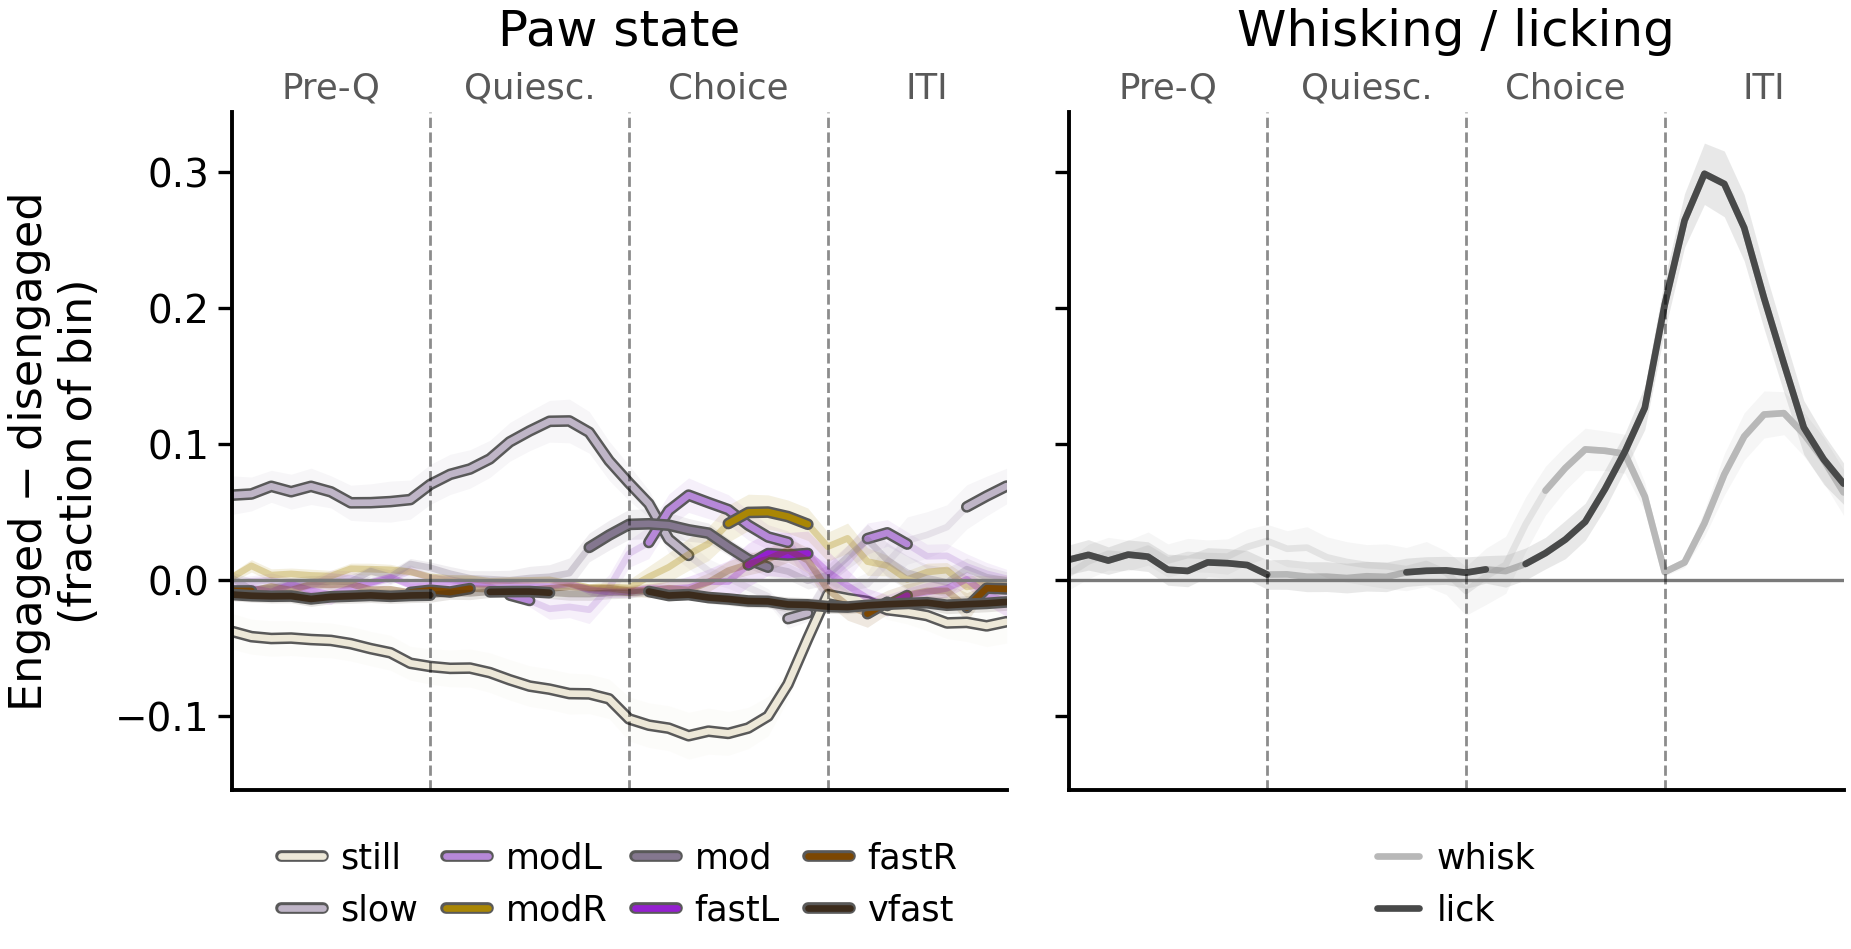

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_A_state_signature_07-10-2026.png, figures/fig_engagement_syllables_A_state_signature_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [5]:
FEAT_LABEL = list(td.PAW_NAMES) + ['whisk', 'lick']
FEAT_COLORS = ps.SYLLABLE_COLORS                      # paw 0..7, whisk, lick
assert len(FEAT_LABEL) == len(FEAT_COLORS) == OCC.shape[2]

def session_contrast(mask_a, mask_b, min_a=1, min_b=MIN_TRIALS_STATE):
    # per session mean OCC on mask_a trials minus mask_b trials, then mean within mouse -> (mice, bins, features)
    out, mice = [], []
    for eid, idx in df.groupby('eid').indices.items():
        a, b = idx[mask_a[idx]], idx[mask_b[idx]]
        if len(a) < min_a or len(b) < min_b:
            continue
        with np.errstate(invalid='ignore'):
            out.append(np.nanmean(OCC[a], axis=0) - np.nanmean(OCC[b], axis=0))
        mice.append(df['mouse_name'].iat[idx[0]])
    out = np.array(out)
    return np.stack([np.nanmean(out[np.array(mice) == m], axis=0) for m in dict.fromkeys(mice)])

def across_mice(D):
    # mean, SEM and FDR q (Wilcoxon against 0, across mice) per (bin, feature)
    mean, sem = np.nanmean(D, 0), np.nanstd(D, 0, ddof=1) / np.sqrt(np.sum(~np.isnan(D), 0))
    p = np.ones(mean.shape)
    for i, j in np.ndindex(mean.shape):
        x = D[:, i, j]; x = x[~np.isnan(x)]
        if len(x) >= 6 and np.any(x != 0):
            p[i, j] = wilcoxon(x).pvalue
    q = multipletests(p.ravel(), method='fdr_bh')[1].reshape(p.shape)
    return mean, sem, q

import matplotlib.patheffects as pe
OUTLINE = [pe.Stroke(linewidth=plt.rcParams['lines.linewidth'] + 0.9, foreground='0.35'), pe.Normal()]

def trace_axes(ax_paw, ax_wl, mean, sem, q, ylabel=None, legend=True):
    # the repo's structural-coefficient style: one trace per syllable along the 40 trial bins,
    # faint where not significant and solid where it is
    x = np.arange(N_BINS_TRIAL)
    for ax, feats in [(ax_paw, range(ps.N_PAW_STATES)), (ax_wl, [8, 9])]:
        for f in feats:
            c = FEAT_COLORS[f]
            ax.fill_between(x, mean[:, f] - sem[:, f], mean[:, f] + sem[:, f], color=c, alpha=0.12, lw=0)
            ax.plot(x, mean[:, f], color=c, alpha=0.3)
            ax.plot(x, np.where(q[:, f] < 0.05, mean[:, f], np.nan), color=c, label=FEAT_LABEL[f],
                    path_effects=OUTLINE if f < ps.N_PAW_STATES else None)
        ax.axhline(0, color=ps.NEUTRAL, lw=0.6)
        ps.epoch_lines(ax, N_BINS_TRIAL, label=True, names=ps.EPOCH_SHORT)
        ax.set_xlim(0, N_BINS_TRIAL - 1); ax.set_xticks([])
    ax_wl.tick_params(labelleft=False)
    if ylabel:
        ax_paw.set_ylabel(ylabel)
    if legend:
        ax_paw.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.04),
                      fontsize=plt.rcParams['legend.fontsize'] * 0.9, handlelength=1.2, columnspacing=0.8)
        ax_wl.legend(frameon=False, ncol=1, loc='upper center', bbox_to_anchor=(0.5, -0.04),
                     fontsize=plt.rcParams['legend.fontsize'] * 0.9, handlelength=1.2)

dis = (df['disengaged'] == 1).to_numpy()
D_state = session_contrast(~dis, dis, min_a=MIN_TRIALS_STATE)
A_mean, A_sem, A_q = across_mice(D_state)
print(f'{len(D_state)} mice; significant (bin, syllable) cells: {(A_q < 0.05).sum()} / {A_q.size}')

def draw_A(fig, spec, legend=True):
    g = spec.subgridspec(1, 2, wspace=0.08)
    ax_p = fig.add_subplot(g[0]); ax_w = fig.add_subplot(g[1], sharey=ax_p)
    trace_axes(ax_p, ax_w, A_mean, A_sem, A_q, ylabel='Engaged − disengaged\n(fraction of bin)', legend=legend)
    ax_p.set_title('Paw state', pad=12); ax_w.set_title('Whisking / licking', pad=12)
    return [ax_p, ax_w]

fig = plt.figure(figsize=(5.2, 2.2))
draw_A(fig, fig.add_gridspec(1, 1)[0])
plt.show()
ps.savefig(fig, f'{FIG}_A_state_signature', svg=True)

## Panel B — syllable use around transitions

As `transition_prediction.ipynb` 3a (`tp_data.event_triggered`): session-centred usage of each syllable per epoch on the trials around each transition (0 = first trial in the new state), transitions preceded by ≥ 5 trials in the old state, averaged within mouse, then mean ± SEM across mice. Trial 0's Choice and ITI come after the choice that defines the new state (shaded).

disengage: 2198 transitions, 56 mice
reengage: 880 transitions, 47 mice


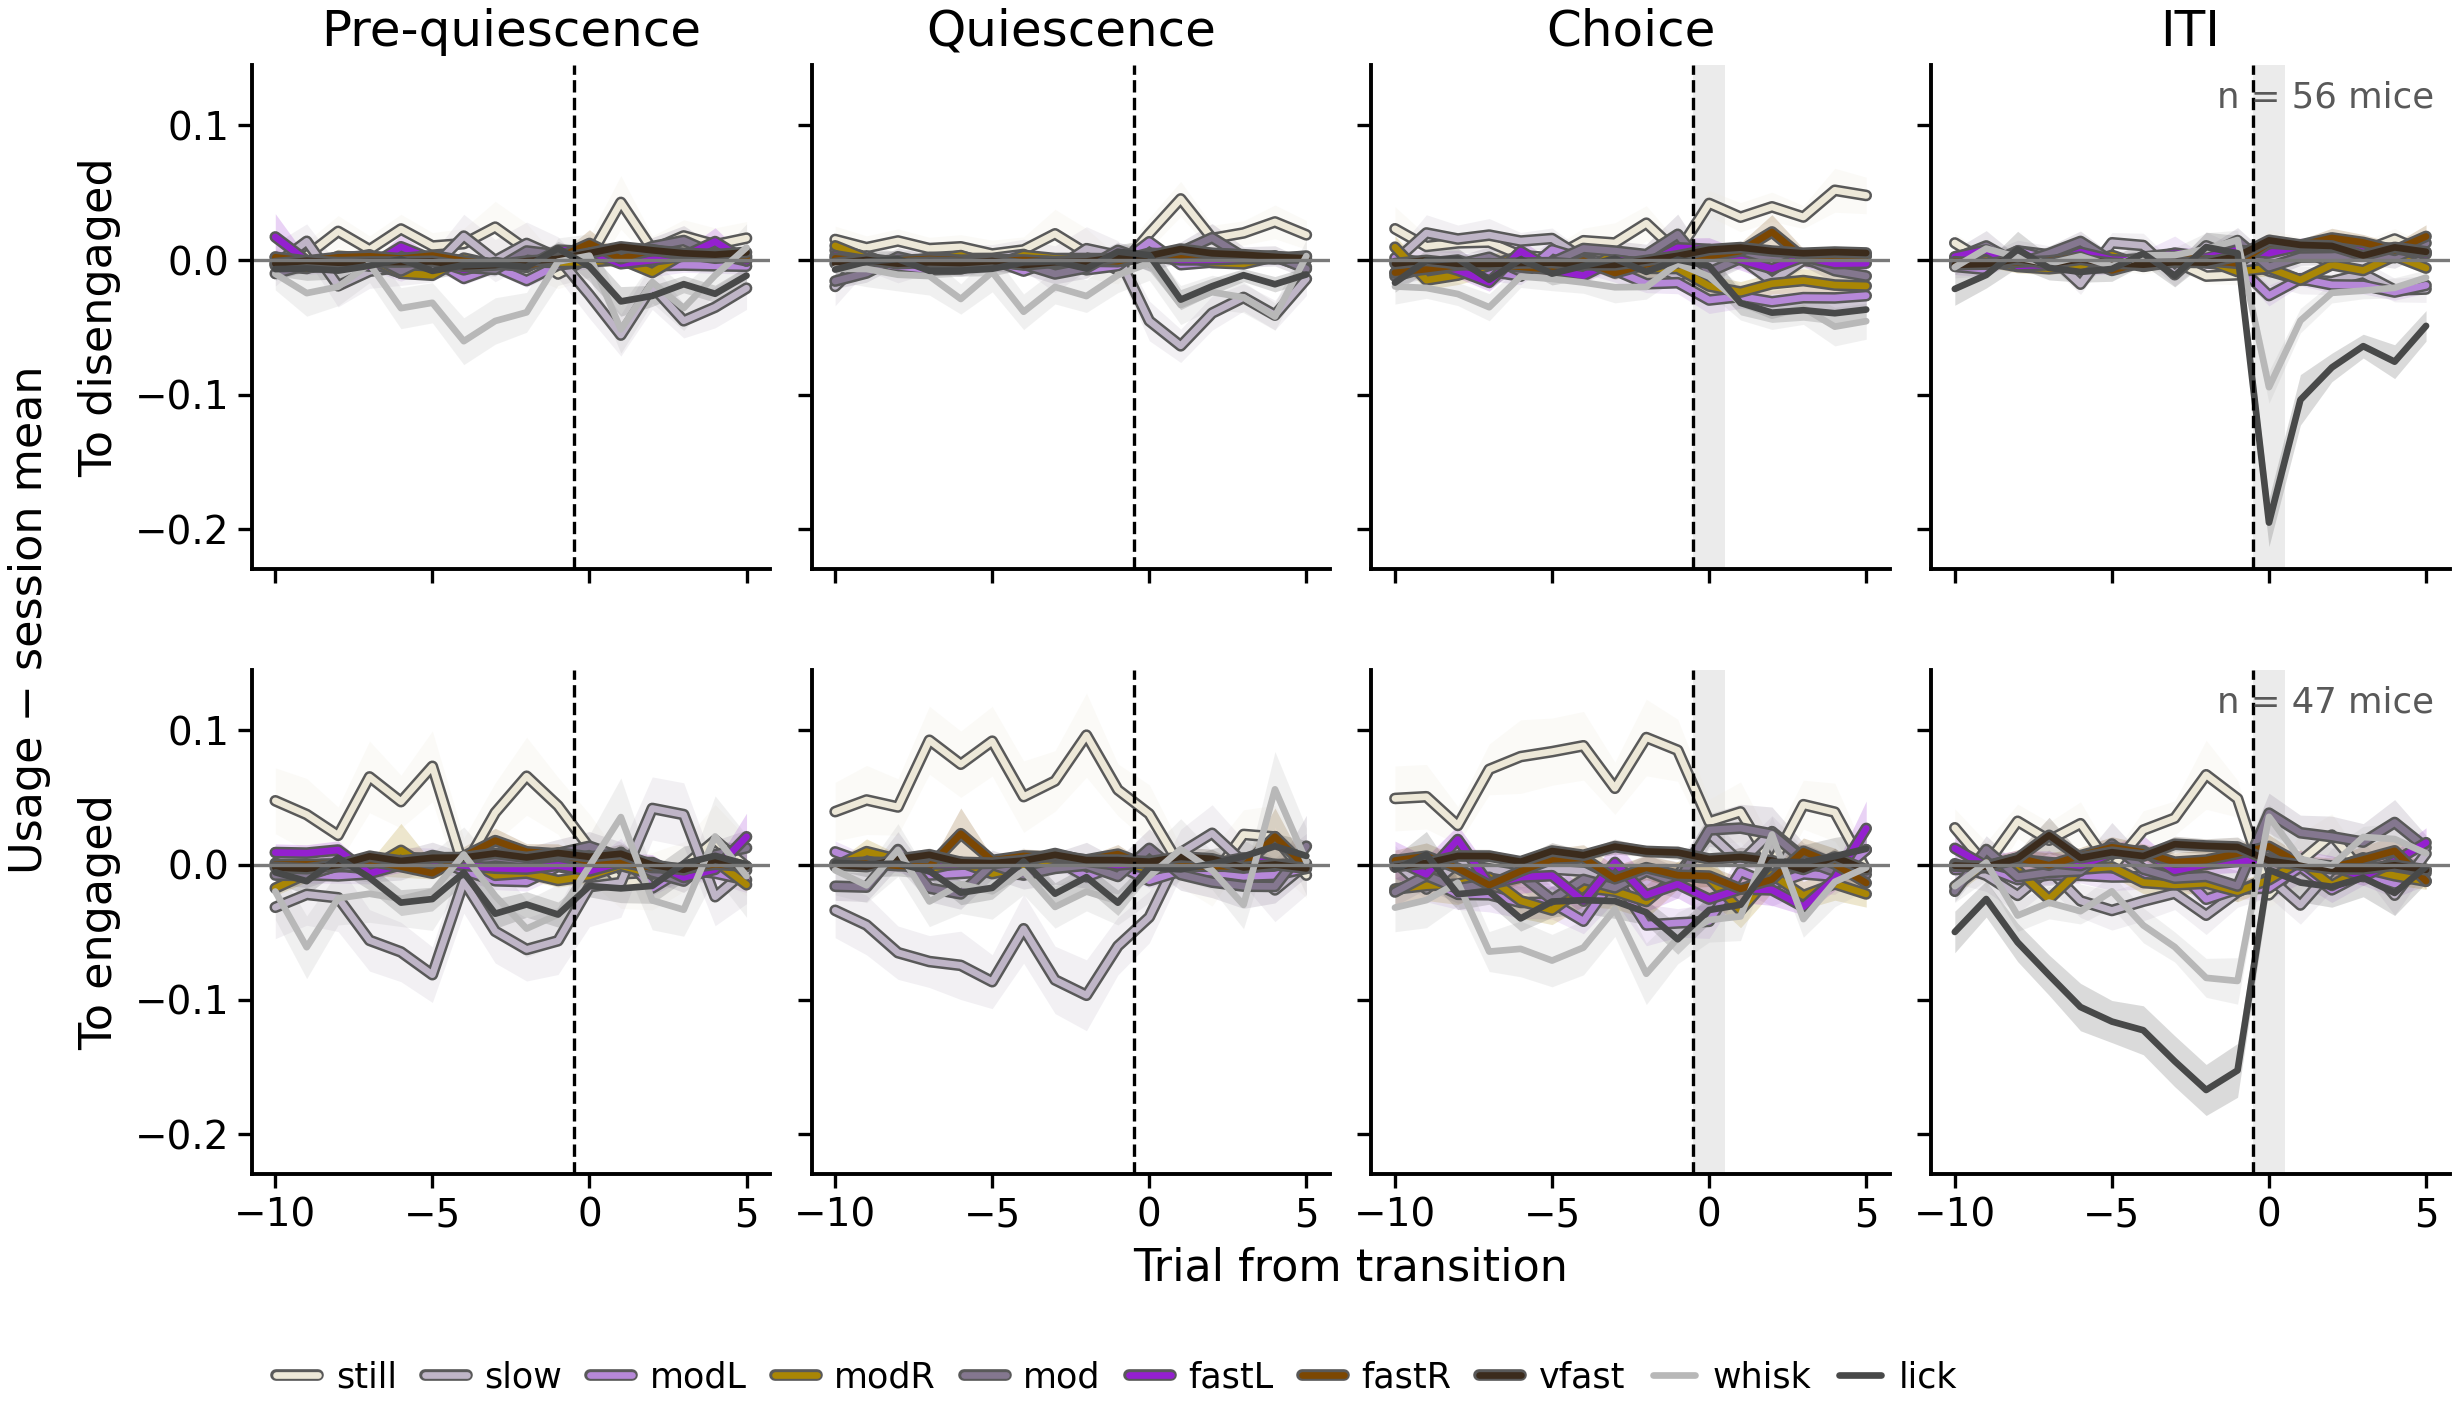

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_B_transition_signature_07-10-2026.png, figures/fig_engagement_syllables_B_transition_signature_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [6]:
ETA = {t: td.event_triggered(df, t, window=ETA_WINDOW) for t in ['disengage', 'reengage']}
EPOCH_FEATS = [f'paw_{p}' for p in td.PAW_NAMES] + ['whisk', 'lick']     # same order as FEAT_LABEL / FEAT_COLORS
for t, e in ETA.items():
    print(f"{t}: {e.attrs['n_events']} transitions, {e.attrs['n_mice']} mice")

def draw_B(fig, spec, legend=True):
    g = spec.subgridspec(2, len(td.EPOCHS), wspace=0.08, hspace=0.2)
    first = fig.add_subplot(g[0, 0])
    axes = np.array([[first if (r, c) == (0, 0) else fig.add_subplot(g[r, c], sharex=first, sharey=first)
                      for c in range(len(td.EPOCHS))] for r in range(2)])
    _draw_B(axes, legend)
    return list(axes.ravel())

def _draw_B(axes, legend):
    for r, (t, label) in enumerate([('disengage', 'To disengaged'), ('reengage', 'To engaged')]):
        e = ETA[t]
        for c, ep in enumerate(td.EPOCHS):
            ax = axes[r, c]
            if ep in ('Choice', 'ITI'):
                ax.axvspan(-0.5, 0.5, color='0.92', lw=0, zorder=0)
            for f, (name, col) in enumerate(zip(EPOCH_FEATS, FEAT_COLORS)):
                d = e[(e['epoch'] == ep) & (e['feature'] == name)].sort_values('rel')
                ax.fill_between(d['rel'], d['mean'] - d['sem'], d['mean'] + d['sem'], color=col, alpha=0.2, lw=0)
                ax.plot(d['rel'], d['mean'], color=col, label=FEAT_LABEL[f],
                        path_effects=OUTLINE if f < ps.N_PAW_STATES else None)
            ax.axvline(-0.5, color='k', ls='--', lw=0.6)
            ax.axhline(0, color=ps.NEUTRAL, lw=0.6)
            if r == 0:
                ax.set_title(ep)
        axes[r, 0].set_ylabel(label)
        axes[r, -1].text(0.97, 0.97, f"n = {e.attrs['n_mice']} mice", transform=axes[r, -1].transAxes,
                         ha='right', va='top', fontsize=plt.rcParams['font.size'] * 0.8, color='0.35')
    # one shared quantity label for both rows, outside the row labels
    # shared labels, placed in points so they do not depend on the panel's width
    axes[1, 0].annotate('Usage − session mean', xy=(0, 1.1), xycoords='axes fraction', xytext=(-40, 0),
                        textcoords='offset points', rotation=90, ha='center', va='center',
                        fontsize=plt.rcParams['axes.labelsize'])
    n_c = axes.shape[1]
    axes[1, 0].annotate('Trial from transition', xy=((n_c * 1.08 - 0.08) / 2, 0), xycoords='axes fraction',
                        xytext=(0, -13), textcoords='offset points', ha='center', va='top',
                        fontsize=plt.rcParams['axes.labelsize'])
    if legend:
        axes[1, 0].legend(frameon=False, ncol=10, loc='upper left', bbox_to_anchor=(0, -0.32),
                          fontsize=plt.rcParams['legend.fontsize'] * 0.9, handlelength=1.2, columnspacing=0.8)
    for ax in axes[0]:
        ax.tick_params(labelbottom=False)
    for ax in axes[:, 1:].ravel():
        ax.tick_params(labelleft=False)

fig = plt.figure(figsize=(7.09, 3.6))
draw_B(fig, fig.add_gridspec(1, 1)[0])
plt.show()
ps.savefig(fig, f'{FIG}_B_transition_signature', svg=True)

## Panel C — how predictable are state and transitions?

Held-out AUC (mice held out, 5 folds) of nested logistic models: task history (`base`), syllables alone, task + syllables. Bars = 95% bootstrap interval over mice. The point of the panel is the *gap* between task history and task + syllables: what syllables add beyond the task history they partly encode.

| column | target | inputs from trial t | lag |
|---|---|---|---|
| State | disengaged at t | all 4 epochs (baseline also gets t's outcome) | `STATE_LAG` |
| Disengage / Re-engage | leave the state at t (hazard) | Pre-quiescence + Quiescence | `TRANSITION_LAG` |

Fits are cached in `figure_generation/cache/` (delete a file to refit).

In [7]:
SETTINGS = [('State', 'disengaged', 'concurrent', STATE_LAG),
            ('Dis-\nengage', 'disengage', 'predictive', TRANSITION_LAG),
            ('Re-\nengage', 'reengage', 'predictive', TRANSITION_LAG)]
MODELS = {'base': 'Task history', 'syll': 'Syllables', 'full': 'Task + syllables'}
MODEL_STYLE = {'base': dict(color=ps.NEUTRAL, marker='o'), 'syll': dict(color='#c06030', marker='o'),
               'full': dict(color='k', marker='o')}

def predictions(target, mode, lag):
    path = CACHE / f'pred_{target}_{mode}_lag{lag}_{STATE_SOURCE}_{CV}.pqt'
    if path.exists():
        return pd.read_parquet(path)
    kw = dict(lag=lag, mode=mode, center=CENTER)
    Xb, Xs, y, meta = td.design(df, target, features='syllables', **kw)
    _, preds, _ = tpm.compare_models(Xb, Xs, y, meta, cv=CV, n_splits=N_SPLITS)
    out = meta[['eid', 'mouse_name', 'trial_id']].assign(y=y, **{m: preds[m] for m in ['base', 'syll', 'full', 'null']})
    out.to_parquet(path)
    return out

def boot_auc(d, model, rng):
    idx = d.groupby('mouse_name').indices
    mice = np.array(list(idx))
    vals = []
    for _ in range(N_BOOT):
        pick = np.concatenate([idx[m] for m in rng.choice(mice, len(mice))])
        vals.append(roc_auc_score(d['y'].values[pick], d[model].values[pick]))
    return np.percentile(vals, [2.5, 97.5])

rng = np.random.default_rng(SEED)
rows = []
for label, target, mode, lag in SETTINGS:
    d = predictions(target, mode, lag)
    for m in MODELS:
        s = tpm.scores(d['y'].values, d[m].values, d['null'].values)
        lo, hi = boot_auc(d, m, rng)
        rows.append(dict(setting=label, model=m, auc=s['auc'], lo=lo, hi=hi, ll_skill=s['ll_skill'],
                         events=s['events'], n=s['n']))
    print(label.replace('\n', ' '), 'done', flush=True)
pred_res = pd.DataFrame(rows)
pred_res.pivot(index='setting', columns='model', values=['auc', 'll_skill']).round(3)

State done


Dis- engage done


Re- engage done


auc               ll_skill              
model          base   full   syll     base   full   syll
setting                                                 
Dis-\nengage  0.617  0.625  0.561    0.016  0.019  0.005
Re-\nengage   0.781  0.774  0.637    0.165  0.160  0.039
State         0.709  0.720  0.636    0.093  0.102  0.041

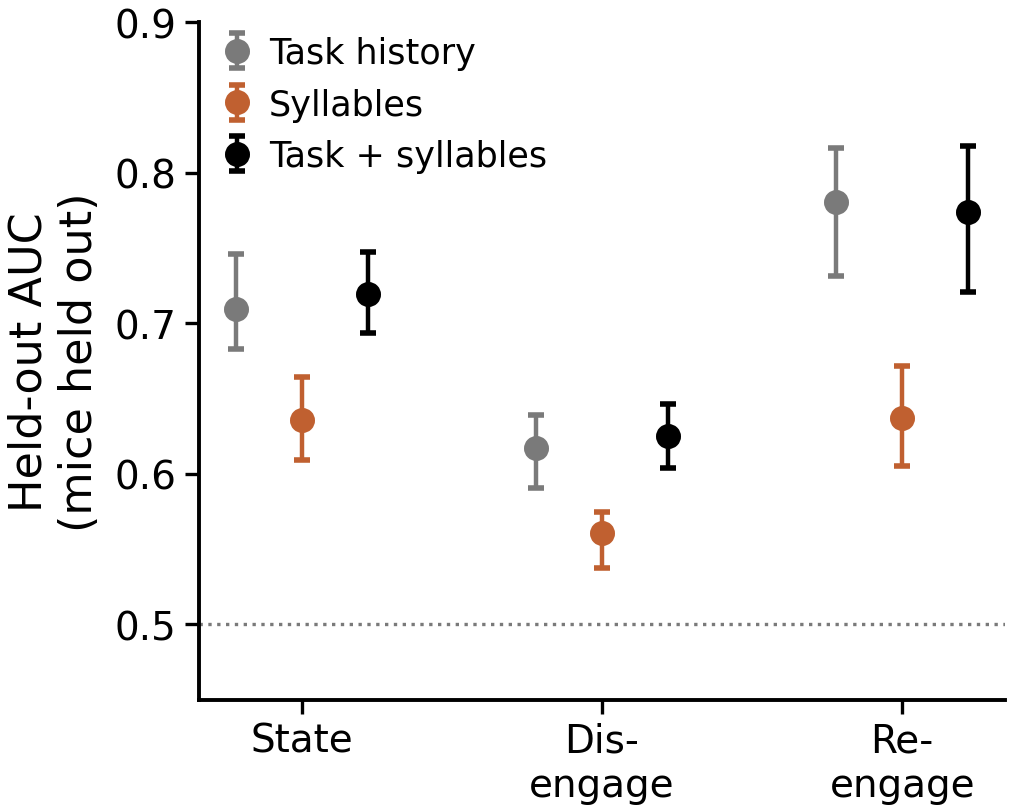

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_C_prediction_07-10-2026.png, figures/fig_engagement_syllables_C_prediction_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True
log-loss skill gained over task history:
setting
Dis-\nengage    0.0023
Re-\nengage    -0.0058
State           0.0091
dtype: float64


In [8]:
def draw_C(fig, spec):
    ax = fig.add_subplot(spec)
    offs = np.linspace(-0.22, 0.22, len(MODELS))
    for i, (label, *_ ) in enumerate(SETTINGS):
        for o, m in zip(offs, MODELS):
            r = pred_res[(pred_res['setting'] == label) & (pred_res['model'] == m)].iloc[0]
            ax.errorbar(i + o, r['auc'], yerr=[[r['auc'] - r['lo']], [r['hi'] - r['auc']]], ls='none',
                        ms=3.5, lw=0.8, label=MODELS[m] if i == 0 else None, **MODEL_STYLE[m])
    ax.axhline(0.5, color=ps.NEUTRAL, lw=0.6, ls=':')
    ax.set_xticks(range(len(SETTINGS))); ax.set_xticklabels([s[0] for s in SETTINGS])
    ax.set_ylabel('Held-out AUC\n(mice held out)'); ax.set_ylim(0.45, 0.9)
    ax.legend(frameon=False, fontsize=plt.rcParams['legend.fontsize'] * 0.9, loc='upper left', ncol=1,
              handletextpad=0.2, borderaxespad=0)
    return [ax]

fig = plt.figure(figsize=(2.6, 2.2))
draw_C(fig, fig.add_gridspec(1, 1)[0])
plt.show()
ps.savefig(fig, f'{FIG}_C_prediction', svg=True)
gain = pred_res.pivot(index='setting', columns='model', values='ll_skill')
print('log-loss skill gained over task history:')
print((gain['full'] - gain['base']).round(4))

## Panel D — the trial-mode map

Each trial (4 epochs × 10 bins of syllables) embedded with UMAP; the density is cut into basins by watershed, one basin = one trial mode. Basins are tinted with the mode colour, shaded by density.

**Palette options** (set `MODE_PALETTE` in Parameters; the choice carries through panels D–F). `umap_pastel` (default) is the original position-based palette (`umap_lab`: hue and saturation from where the mode sits in the map) at CIELAB lightness 76 / chroma 40 instead of 62 / 55. The two data-driven ones use the map's own hierarchy: neighbouring basins are separated by a density saddle, the *barrier* between them is the relative dip (1 − saddle / lower peak), and single-linkage on the barriers gives the order in which basins merge (dendrogram below the maps).
* `families` — the hierarchy cut at `FAMILY_BARRIER`; one hue family per group, and inside a family the hue drifts and the lightness steps along the tree order, so modes that merge first look most alike.
* `barrier` — no cut: hue runs continuously along the tree order, spaced by the barriers, so the colour difference between two modes reflects how deep a valley separates them.
* `glasbey`, `tableau` — categorical, no implied grouping. `umap_lab` — the original.

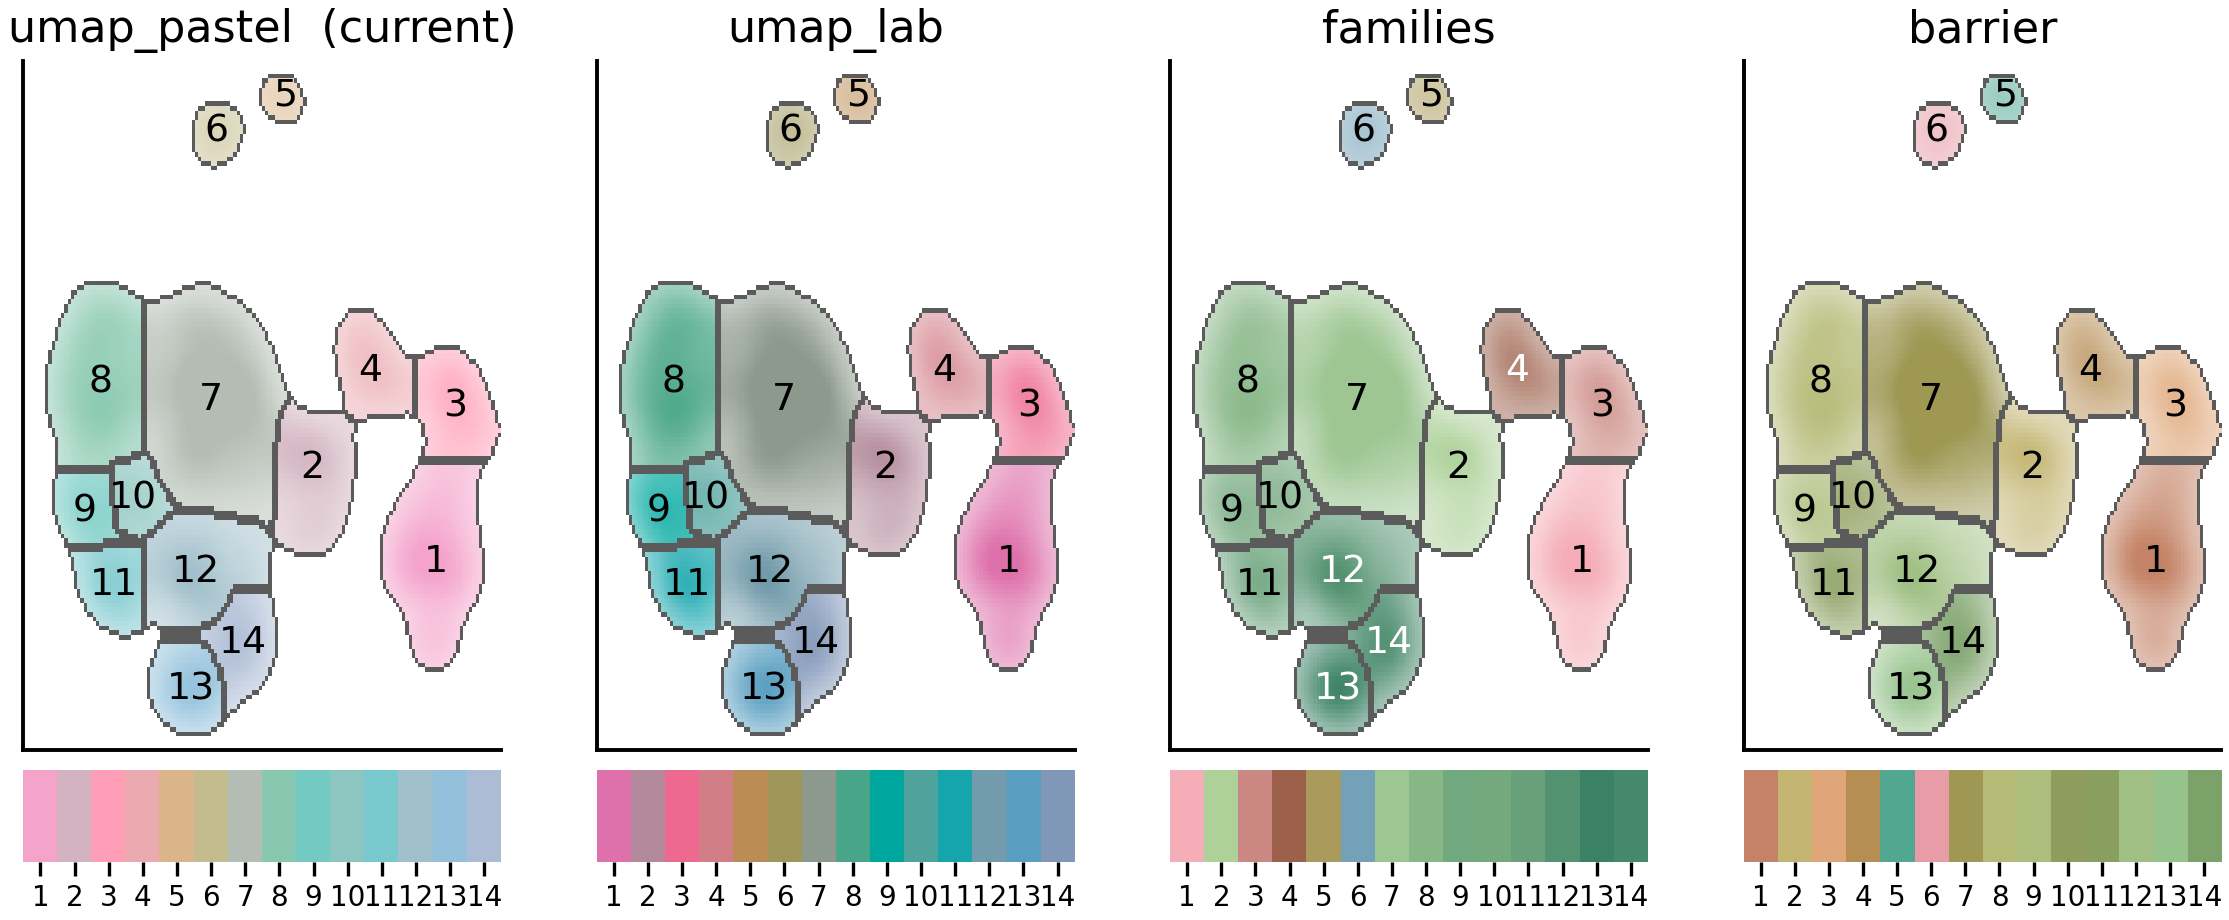

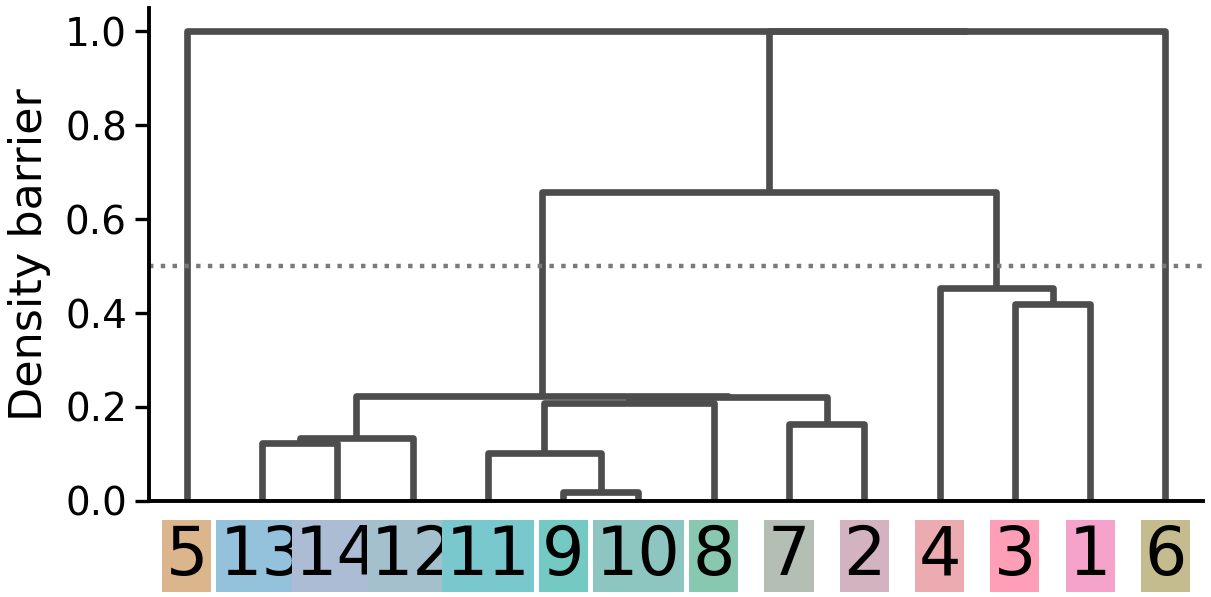

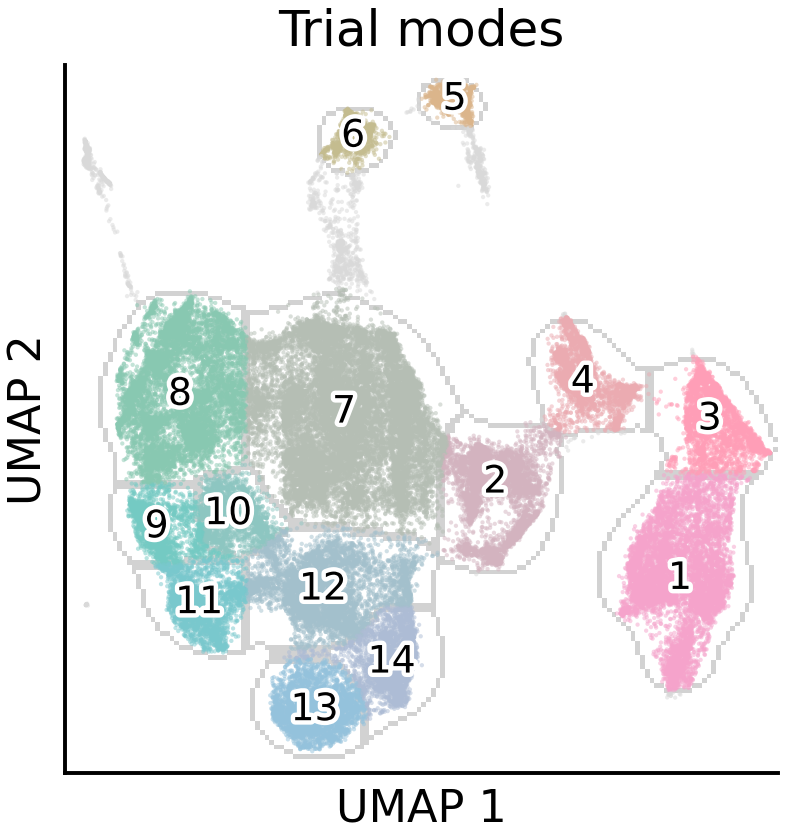

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_D_mode_map_07-10-2026.png, figures/fig_engagement_syllables_D_mode_map_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [9]:
from skimage.segmentation import find_boundaries
Z, labels, (xmin, xmax, ymin, ymax) = fit['Z'], fit['labels'], fit['bounds']
cen = trials.dropna(subset=['trial_cluster']).groupby('trial_cluster')[['embedding_x', 'embedding_y']].median()
edge = find_boundaries(labels, mode='inner')

MAP_POINTS = 60_000      # trials drawn in the scatter version of the map (random subsample)
_emb = trials.dropna(subset=['embedding_x']).sample(MAP_POINTS, random_state=SEED)

def draw_map(ax, colors, numbers=True, style='fill'):
    if style == 'scatter':
        # every dot is a trial, in its mode's colour; trials on the KDE background in light grey
        cl = _emb['trial_cluster'].to_numpy()
        col = np.array([to_rgb(colors[k]) if k == k else (0.85, 0.85, 0.85) for k in cl])
        ax.scatter(_emb['embedding_x'], _emb['embedding_y'], c=col, s=0.6, lw=0, alpha=0.5, rasterized=True)
        ax.imshow(np.rot90(np.where(edge, 1.0, np.nan)), extent=[xmin, xmax, ymin, ymax], aspect='auto',
                  cmap='Greys', vmin=0, vmax=2.5, interpolation='nearest', alpha=0.6)
        if numbers:
            for k in ORDER:
                ax.text(*cen.loc[float(k)], str(MODE_NAME[k]), ha='center', va='center',
                        fontsize=plt.rcParams['font.size'] * 0.85, color='k',
                        path_effects=[pe.withStroke(linewidth=1.6, foreground='white')])
        ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), xticks=[], yticks=[])
        return
    dens = Z / Z.max()
    rgb = np.ones(labels.shape + (3,))
    for k in ORDER:
        rgb[labels == k] = to_rgb(colors[float(k)])
    shade = 0.35 + 0.65 * np.clip(dens / np.percentile(dens[labels > 0], 95), 0, 1)
    img = 1 - (1 - rgb) * shade[..., None]   # density shading: pale at basin edges, full colour at peaks
    img[labels == 0] = 1.0
    ax.imshow(np.rot90(img), extent=[xmin, xmax, ymin, ymax], aspect='auto', interpolation='nearest')
    ax.imshow(np.rot90(np.where(edge, 1.0, np.nan)), extent=[xmin, xmax, ymin, ymax], aspect='auto',
              cmap='Greys', vmin=0, vmax=1.4, interpolation='nearest')
    if numbers:
        for k in ORDER:
            ax.text(*cen.loc[float(k)], str(MODE_NAME[k]), ha='center', va='center',
                    fontsize=plt.rcParams['font.size'] * 0.85, color=ink_on(colors[float(k)]))
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), xticks=[], yticks=[])

# palette comparison (not saved)
names = ['umap_pastel', 'umap_lab', 'families', 'barrier']
fig, axes = plt.subplots(2, len(names), figsize=(7.09, 2.6), gridspec_kw=dict(height_ratios=[3, 0.4], hspace=0.05))
for j, nm in enumerate(names):
    pal = mode_palette(nm)
    draw_map(axes[0, j], pal)
    axes[0, j].set_title(nm + ('  (current)' if nm == MODE_PALETTE else ''), fontsize=plt.rcParams['font.size'])
    axes[1, j].imshow(np.array([to_rgb(pal[float(k)]) for k in ORDER])[None], aspect='auto')
    axes[1, j].set_xticks(range(K_MODES)); axes[1, j].set_xticklabels([MODE_NAME[k] for k in ORDER], fontsize=5)
    axes[1, j].set_yticks([])
    for sp_ in axes[1, j].spines.values():
        sp_.set_visible(False)
plt.show()

# the hierarchy the data-driven palettes come from
fig, ax = plt.subplots(figsize=(3.4, 1.6))
dendrogram(TREE, labels=[MODE_NAME[k] for k in BASIN_IDS], ax=ax, color_threshold=0, above_threshold_color='0.3')
for tl in ax.get_xticklabels():
    k = [kk for kk in BASIN_IDS if MODE_NAME[kk] == int(tl.get_text())][0]
    tl.set_bbox(dict(facecolor=mcolor(k), edgecolor='none', pad=0.6)); tl.set_color(ink_on(mcolor(k)))
ax.axhline(FAMILY_BARRIER, color=ps.NEUTRAL, ls=':', lw=0.8)
ax.set_ylabel('Density barrier'); ax.set_ylim(0, 1.05)
plt.show()

def draw_D(fig, spec):
    ax = fig.add_subplot(spec)
    draw_map(ax, MODE_COLORS, style='scatter')
    ax.set(xlabel='UMAP 1', ylabel='UMAP 2', title='Trial modes')
    return [ax]

fig = plt.figure(figsize=(2.3, 2.3))
draw_D(fig, fig.add_gridspec(1, 1)[0])
plt.show()
ps.savefig(fig, f'{FIG}_D_mode_map', svg=True)

## Panel E — what each mode looks like

One row per mode (colour-wheel order): the most common paw state in each of the 40 bins (4 epochs × 10), with P(whisking) and P(licking) as grey bands underneath (darker = more likely). Side columns, all computed per mouse and shown as the median across mice (dot) with the interquartile range across mice (line); a mouse enters a mode's cell with ≥ `MIN_TRIALS_CELL` trials in it:
* share of the mouse's trials in the mode;
* accuracy;
* log reaction time (natural log of the per-mouse median, in s; clipped at 30 ms; 0 = 1 s), as in the LD1 behaviour panels;
* P(left block | mode) − the session's rate, over biased-block trials (p(left) = 0.8 vs 0.2);
* P(disengaged | mode) − the session's rate.

For the two excess columns, filled = FDR q < 0.05 (Wilcoxon across mice, FDR over modes). Vertical lines mark zero (and chance, 0.5, for accuracy).

In [10]:
def fingerprint(k):
    _, seqs = tmodes.trial_matrix_from_trials(trials[trials['trial_cluster'] == k])
    paw, whisk, lick = ps.decode_syllables(seqs)
    counts = np.stack([(paw == s).sum(0) for s in range(ps.N_PAW_STATES)])
    return counts.argmax(0), np.nanmean(whisk, 0), np.nanmean(lick, 0)

FP = {k: fingerprint(float(k)) for k in ORDER}

tm_ = trials.dropna(subset=['trial_cluster']).copy()
tm_['trial_cluster'] = tm_['trial_cluster'].astype(int)
tm_['block'] = tm_['trial_type'].str.split().str[2].astype(float)       # = probabilityLeft (97% match to the states file)
tm_['rt'] = tm_['reaction'].clip(lower=0.03)                             # as trial_modes_proficient

def mouse_table(d, value, stat='mean', min_n=MIN_TRIALS_CELL):
    # mice x modes table of `stat` of `value`, cells with < min_n trials -> NaN
    g = d.groupby(['mouse_name', 'trial_cluster'])[value].agg([stat, 'size'])
    return g[stat].where(g['size'] >= min_n).unstack()

def session_excess(d, value):
    # per session P(value | mode) - P(value), mean within mouse -> mice x modes
    d = d.assign(_rate=d.groupby('session')[value].transform('mean'))
    c = d.groupby(['mouse_name', 'session', 'trial_cluster']).agg(p=(value, 'mean'), b=('_rate', 'first'), n=(value, 'size'))
    c = c[c['n'] >= MIN_TRIALS_CELL]
    return (c['p'] - c['b']).groupby(['mouse_name', 'trial_cluster']).mean().unstack()

PER_MOUSE = {
    'share': tm_.groupby('mouse_name')['trial_cluster'].value_counts(normalize=True).unstack(fill_value=0) * 100,
    'accuracy': mouse_table(tm_, 'correct'),
    'rt': np.log(mouse_table(tm_.dropna(subset=['rt']), 'rt', 'median')),     # log of the per-mouse median RT (s)
    'left_excess': session_excess(tm_[tm_['block'] != 0.5].assign(left=lambda d: (d['block'] == 0.8).astype(float)), 'left'),
}
d = df[df['trial_mode'] >= 0].rename(columns={'eid': 'session', 'trial_mode': 'trial_cluster'})
PER_MOUSE['dis_excess'] = session_excess(d, 'disengaged')

rows = []
for col, tab in PER_MOUSE.items():
    for k in tab.columns:
        x = tab[k].dropna()
        p = wilcoxon(x).pvalue if col.endswith('excess') and len(x) >= 6 else np.nan
        rows.append(dict(mode=int(k), col=col, median=x.median(), q25=x.quantile(.25), q75=x.quantile(.75), n_mice=len(x), p=p))
summ = pd.DataFrame(rows)
for col in ['left_excess', 'dis_excess']:
    sel = (summ['col'] == col) & summ['p'].notna()
    summ.loc[sel, 'q'] = multipletests(summ.loc[sel, 'p'], method='fdr_bh')[1]
mode_tab = summ.pivot(index='mode', columns='col', values=['median', 'q25', 'q75', 'q'])
mode_tab[('name', '')] = mode_tab.index.map(MODE_NAME)
mode_tab.loc[ORDER, 'median'].round(3)

col,accuracy,dis_excess,left_excess,rt,share
mode,,,,,
2,0.833,-0.004,0.015,-1.832,8.648
6,0.589,0.051,-0.013,1.053,5.858
9,0.581,0.088,-0.014,1.092,4.414
12,0.745,0.009,-0.019,-1.664,3.250
14,0.835,-0.018,-0.006,-1.711,0.035
13,0.874,-0.046,-0.020,-1.956,0.213
1,0.845,-0.011,0.001,-2.029,25.226
5,0.905,-0.012,0.004,-2.071,13.232
10,0.906,-0.005,-0.079,-1.975,2.378


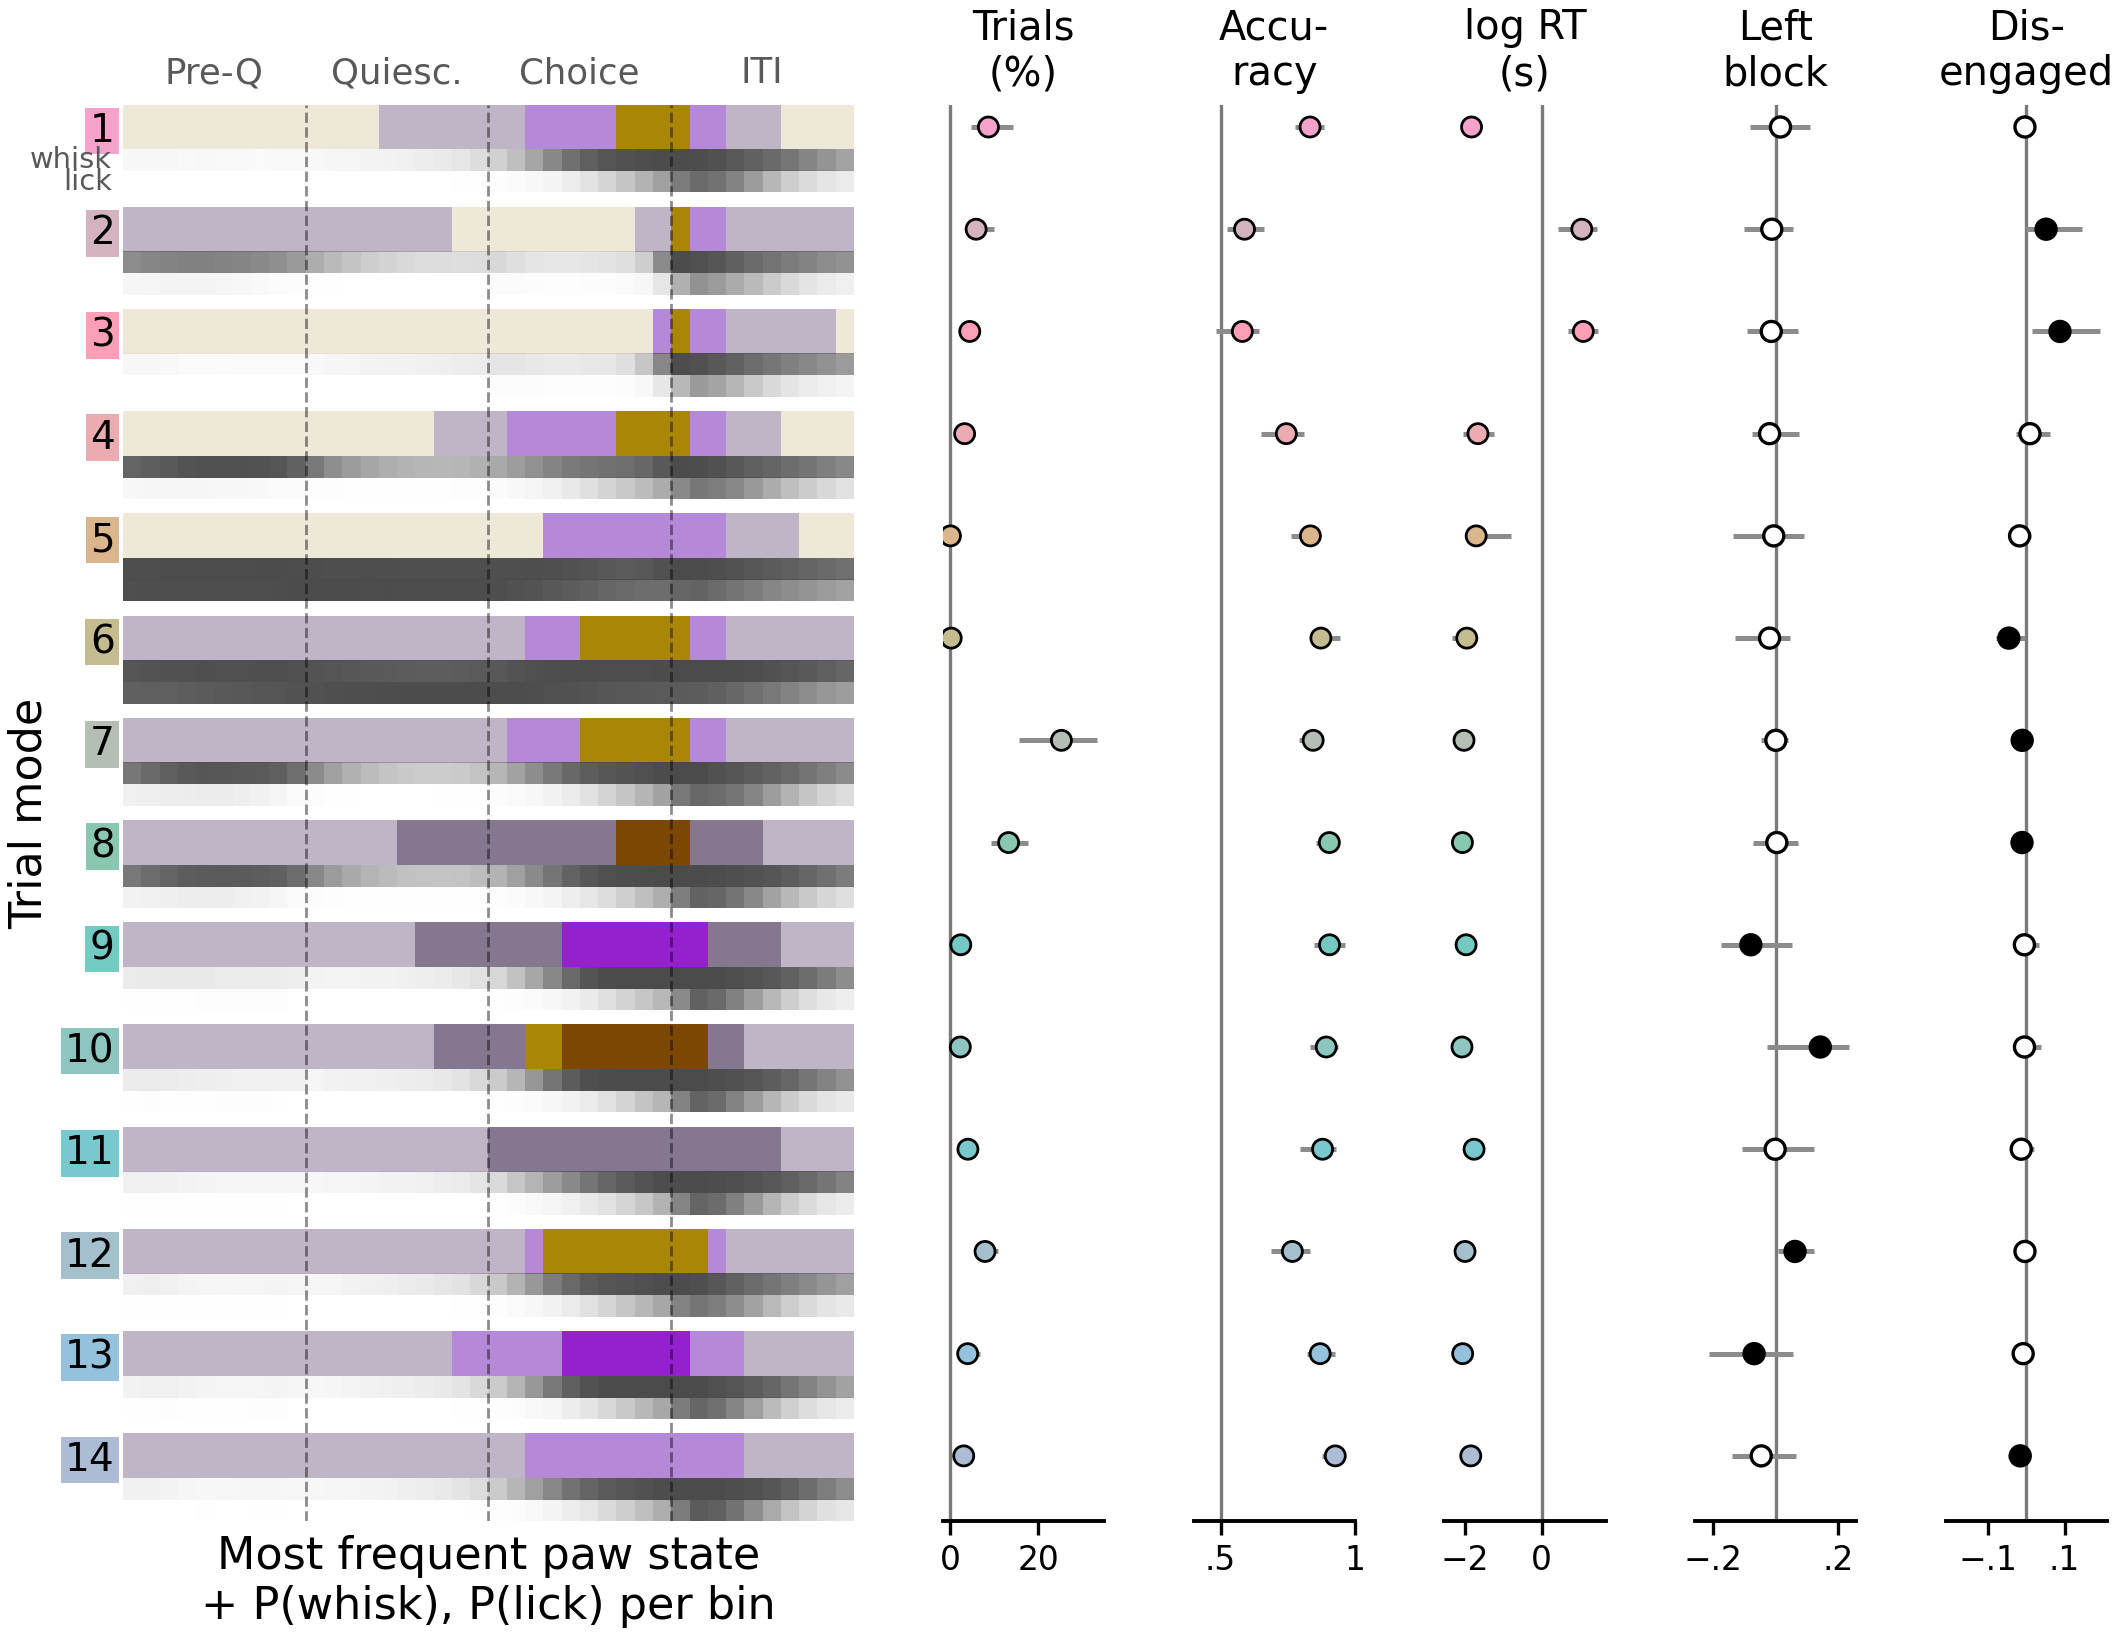

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_E_mode_barcodes_07-10-2026.png, figures/fig_engagement_syllables_E_mode_barcodes_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [11]:
WL_GREY = '#4a4a4a'
PAW_H, WL_H, GAP = 0.44, 0.21, 0.14       # row heights within one mode (sum = 1): paw, whisk, lick, gap
paw_rgb = np.array([to_rgb(c) for c in ps.PAW_STATE_COLORS])

n_bins = 40
T = mode_tab.loc[ORDER]
ys = np.arange(K_MODES) + PAW_H / 2
# short column titles; the excess columns are P(. | mode) - the session's rate (say so in the legend)
SIDE = [('share', 'Trials\n(%)', [0], None),
        ('accuracy', 'Accu-\nracy', [0.5], (0.4, 1.0)),
        ('rt', 'log RT\n(s)', [0], None),
        ('left_excess', 'Left\nblock', [0], None),
        ('dis_excess', 'Dis-\nengaged', [0], None)]
TICKS = {'share': ([0, 20],), 'rt': ([-2, 0],), 'accuracy': ([0.5, 1], ['.5', '1']),
         'left_excess': ([-0.2, 0.2], ['−.2', '.2']), 'dis_excess': ([-0.1, 0.1], ['−.1', '.1'])}

def draw_E(fig, spec):
    gs = spec.subgridspec(1, 1 + len(SIDE), width_ratios=[3.4] + [0.75] * len(SIDE), wspace=0.35)
    ax = fig.add_subplot(gs[0])
    axes_out = [ax]
    for i, k in enumerate(ORDER):
        paw, whisk, lick = FP[k]
        y0 = i
        ax.imshow(paw_rgb[paw][None], extent=[0, n_bins, y0 + PAW_H, y0], aspect='auto', interpolation='nearest')
        for j, (pr, off) in enumerate([(whisk, PAW_H), (lick, PAW_H + WL_H)]):
            band = np.ones((1, n_bins, 4)); band[..., :3] = to_rgb(WL_GREY); band[..., 3] = pr
            ax.imshow(band, extent=[0, n_bins, y0 + off + WL_H, y0 + off], aspect='auto', interpolation='nearest')
    ax.set_ylim(K_MODES - GAP, 0)
    ax.set_xlim(0, n_bins)
    ps.epoch_lines(ax, n_bins, label=True, names=ps.EPOCH_SHORT)
    ax.set_xticks([])
    ax.set_xlabel('Most frequent paw state\n+ P(whisk), P(lick) per bin')
    ax.set_yticks(np.arange(K_MODES) + PAW_H / 2)
    ax.set_yticklabels([MODE_NAME[k] for k in ORDER])
    for tl, k in zip(ax.get_yticklabels(), ORDER):
        tl.set_bbox(dict(facecolor=mcolor(k), edgecolor='none', pad=0.8)); tl.set_color(ink_on(mcolor(k)))
    ax.tick_params(axis='y', length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_ylabel('Trial mode')
    for off, nm in [(PAW_H + WL_H / 2, 'whisk'), (PAW_H + 1.5 * WL_H, 'lick')]:    # name the bands once, under mode 1
        ax.text(-0.6, off, nm, va='center', ha='right', fontsize=plt.rcParams['font.size'] * 0.65, color='0.35',
                clip_on=False)

    for j, (col, title, refs, xlim) in enumerate(SIDE, start=1):
        a = fig.add_subplot(gs[j], sharey=ax)
        axes_out.append(a)
        med, lo, hi = T[('median', col)].to_numpy(), T[('q25', col)].to_numpy(), T[('q75', col)].to_numpy()
        for r_ in refs:
            a.axvline(r_, color=ps.NEUTRAL, lw=0.6, zorder=0)
        a.hlines(ys, lo, hi, color='0.55', lw=0.9, zorder=1)
        if col.endswith('excess'):
            filled = (T[('q', col)] < 0.05).to_numpy()
            a.scatter(med, ys, s=13, c=['k' if f_ else 'white' for f_ in filled], edgecolors='k', lw=0.6, zorder=3)
            lim = np.nanmax(np.abs(np.r_[lo, hi])) * 1.1
            a.set_xlim(-lim, lim)
        else:
            a.scatter(med, ys, s=13, c=[mcolor(k) for k in ORDER], edgecolors='k', lw=0.5, zorder=3)
        if xlim:
            a.set_xlim(*xlim)
        if col in TICKS:
            a.set_xticks(*TICKS[col])
        a.set_title(title, fontsize=plt.rcParams['font.size'] * 0.9)
        a.tick_params(axis='y', left=False, labelleft=False)
        a.spines['left'].set_visible(False)
        a.tick_params(axis='x', labelsize=plt.rcParams['xtick.labelsize'] * 0.85)
    return axes_out

fig = plt.figure(figsize=(6.4, 4.6))
draw_E(fig, fig.add_gridspec(1, 1)[0])
plt.show()
ps.savefig(fig, f'{FIG}_E_mode_barcodes', svg=True)

## Panel F — mode usage per mouse, along LD1

Sessions with an LD1 value; usage averaged over a mouse's sessions; mice sorted by mouse-mean LD1 (colour strip underneath).

260 sessions, 56 mice


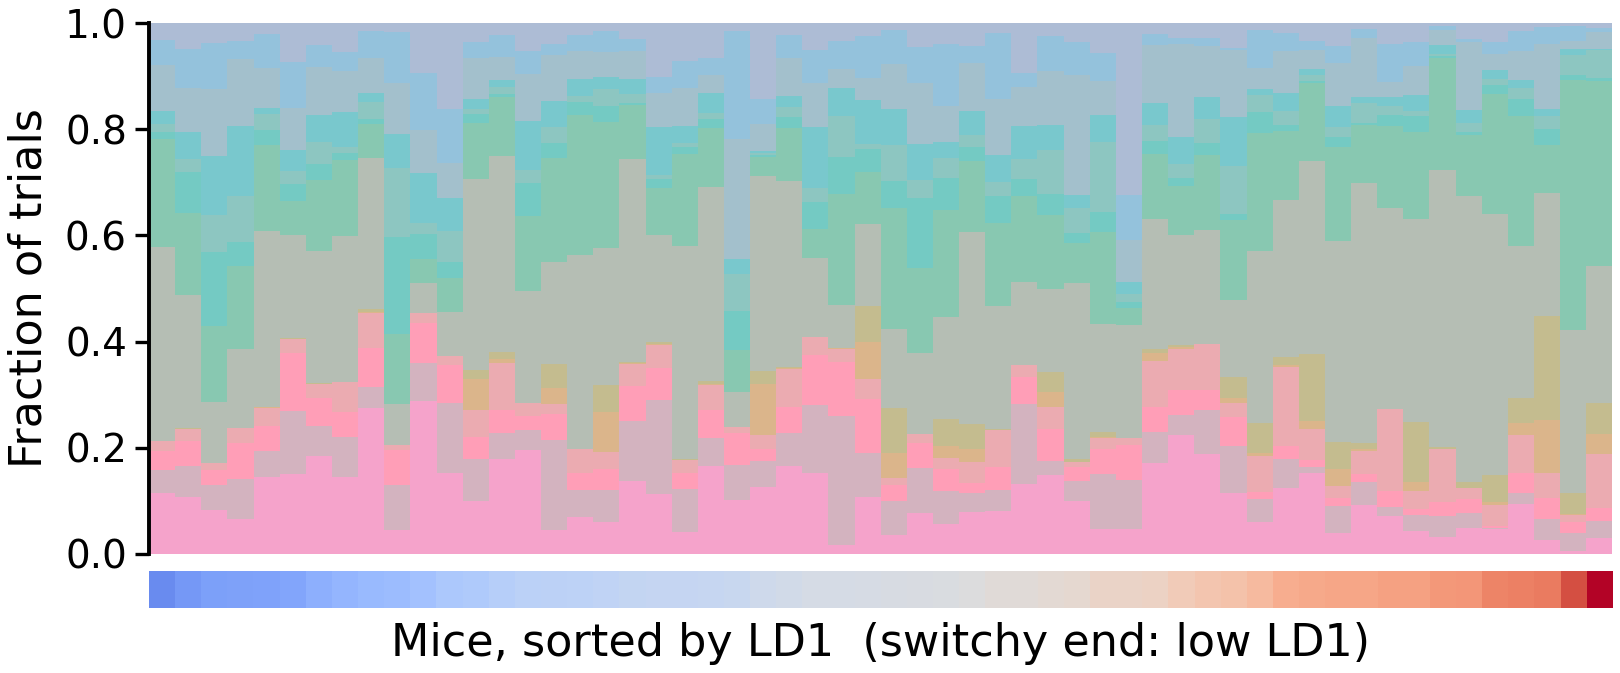

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_F_usage_by_mouse_07-10-2026.png, figures/fig_engagement_syllables_F_usage_by_mouse_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [12]:
mt = trials.dropna(subset=['trial_cluster']).copy()
mt['trial_cluster'] = mt['trial_cluster'].astype(int)
mt = mt[mt['session'].isin(lda['session'])]
use = (mt.groupby('session')['trial_cluster'].value_counts(normalize=True).unstack(fill_value=0)
       .reindex(columns=ORDER, fill_value=0))
use_sess = use.reset_index().merge(lda[['session', 'mouse_name', 'lab', 'lda_1']], on='session')
use_mouse = use_sess.groupby('mouse_name')[ORDER + ['lda_1']].mean().sort_values('lda_1')
print(f'{len(use_sess)} sessions, {len(use_mouse)} mice')

fig = plt.figure(figsize=(4.72, 1.9))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 0.07], hspace=0.06)
ax, ax_s = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
x = np.arange(len(use_mouse))
bottom = np.zeros(len(use_mouse))
for k in ORDER:
    ax.bar(x, use_mouse[k], bottom=bottom, width=1.0, color=mcolor(k), lw=0)
    bottom += use_mouse[k].to_numpy()
ax.set(xlim=(-0.5, len(x) - 0.5), ylim=(0, 1), ylabel='Fraction of trials', xticks=[])
ax.spines['bottom'].set_visible(False)
ax_s.imshow(ps.ld1_colors(use_mouse['lda_1'].to_numpy())[None], aspect='auto', extent=[-0.5, len(x) - 0.5, 0, 1])
ax_s.set_yticks([]); ax_s.set_xticks([])
for s in ax_s.spines.values():
    s.set_visible(False)
ax_s.set_xlabel(f'Mice, sorted by LD1  (switchy end: {SWITCHY_END} LD1)')
plt.show()
ps.savefig(fig, f'{FIG}_F_usage_by_mouse', svg=True)

## Panel G — mode-use entropy vs LD1

Same estimator as `trial_mode_entropy.ipynb`: Shannon entropy of a session's mode-usage distribution, normalised by log(K), averaged over `N_SUB` subsamples of the shortest session's trial count (plug-in entropy is biased low for small samples). Mice = mean over sessions.

260 sessions, 56 mice, subsampled to 369 trials
         n_mice     rho      p  rho_lab_centred  p_lab_centred  rho_within  p_within
y                                                                                   
H_modes      56 -0.3895  0.003          -0.4714         0.0002     -0.0893     0.151


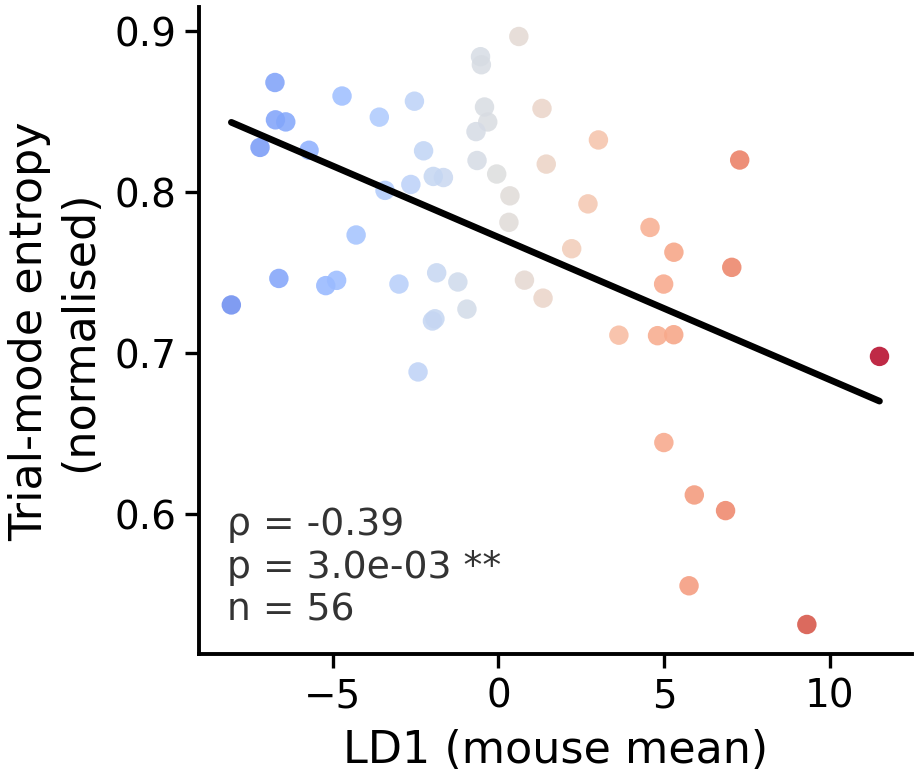

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_G_entropy_vs_ld1_07-10-2026.png, figures/fig_engagement_syllables_G_entropy_vs_ld1_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [13]:
def entropy(counts):
    p = counts[counts > 0] / counts.sum()
    return -(p * np.log(p)).sum()

N_TRIALS = int(mt.groupby('session').size().min())
rng = np.random.default_rng(SEED)
rows = []
for s, g in mt.groupby('session'):
    lab_ = g['trial_cluster'].to_numpy()
    sub = [entropy(np.bincount(rng.choice(lab_, N_TRIALS, replace=False), minlength=max(ORDER) + 1))
           for _ in range(N_SUB)]
    rows.append(dict(session=s, H_modes=np.mean(sub) / np.log(K_MODES), accuracy=g['correct'].mean(), n_trials=len(g)))
ent = (pd.DataFrame(rows).merge(lda[['session', 'mouse_name', 'lab', 'lda_1']], on='session')
       .merge(eng_ax, on='session', how='left'))
print(f'{len(ent)} sessions, {ent["mouse_name"].nunique()} mice, subsampled to {N_TRIALS} trials')
print(rho_table(ent, 'lda_1', ['H_modes']).round(4))
ent_mouse = to_mouse(ent, ['H_modes', 'switch_rate', 'accuracy'])

def draw_G(fig, spec):
    ax = fig.add_subplot(spec)
    ps.corr_panel(ax, ent_mouse['lda_1'], ent_mouse['H_modes'], method='spearman', annotate='lower left',
                  xlabel='LD1 (mouse mean)', ylabel='Trial-mode entropy\n(normalised)')
    return [ax]

fig = plt.figure(figsize=(2.3, 2.1))
draw_G(fig, fig.add_gridspec(1, 1)[0])
plt.show()
ps.savefig(fig, f'{FIG}_G_entropy_vs_ld1', svg=True)

## Panel H — check 1: does mode entropy track engagement switching?

The argument "LD1 tracks switchiness, so it should track entropy" needs this link shown directly. Mouse level, plus a partial on LD1: if entropy relates to switching only *through* LD1, the partial vanishes.

         n_mice     rho       p  rho_lab_centred  p_lab_centred  rho_within  p_within
y                                                                                    
H_modes      56  0.1274  0.3494           0.1613         0.2349     -0.0882    0.1696
mouse level, partial on lda_1: rho = -0.069, p = 0.612
mouse level, partial on frac_disengaged: rho = 0.120, p = 0.38
mouse level, partial on accuracy: rho = 0.125, p = 0.358


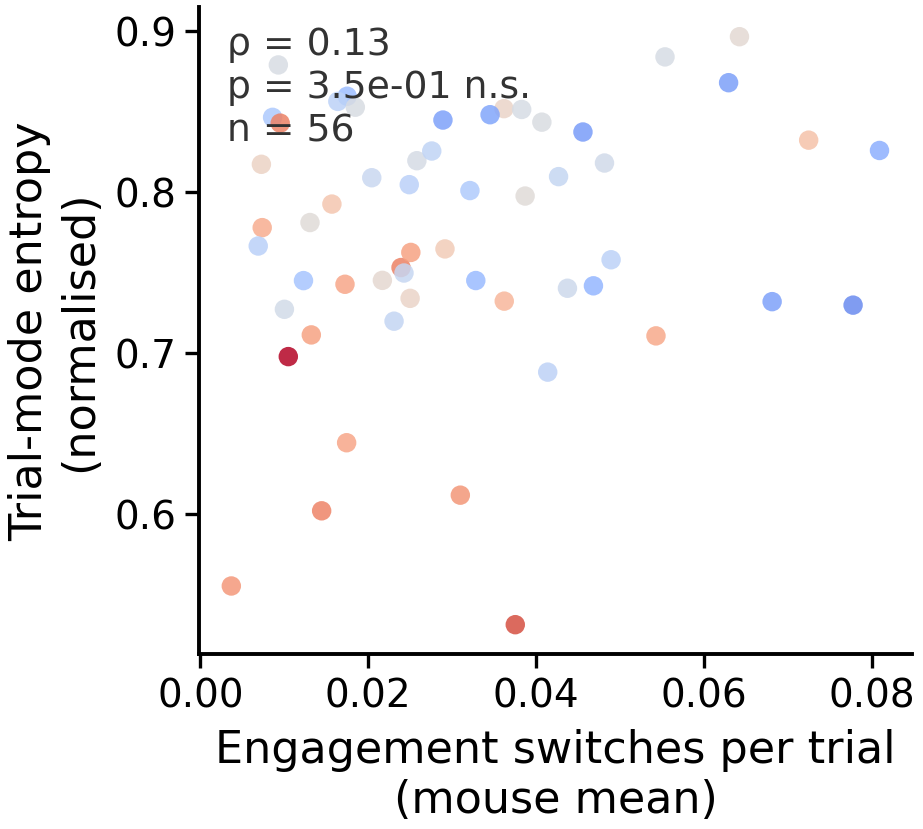

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_H_entropy_vs_switching_07-10-2026.png, figures/fig_engagement_syllables_H_entropy_vs_switching_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [14]:
def resid(y, X):
    X = np.column_stack([np.ones(len(y))] + [np.asarray(x, float) for x in X])
    return y - X @ np.linalg.lstsq(X, y, rcond=None)[0]

e = ent.dropna(subset=['switch_rate'])
print(rho_table(e, 'switch_rate', ['H_modes']).round(4))
m = to_mouse(e, ['H_modes', 'switch_rate', 'frac_disengaged', 'accuracy'])
for ctrl in [['lda_1'], ['frac_disengaged'], ['accuracy']]:
    r = spearmanr(resid(m['switch_rate'].to_numpy(), [m[c] for c in ctrl]), resid(m['H_modes'].to_numpy(), [m[c] for c in ctrl]))
    print(f'mouse level, partial on {ctrl[0]}: rho = {r.statistic:.3f}, p = {r.pvalue:.3g}')

fig, ax = plt.subplots(figsize=(2.3, 2.1))
ps.corr_panel(ax, m['switch_rate'], m['H_modes'], color=ps.ld1_colors(m['lda_1'].to_numpy()), method='spearman',
              xlabel='Engagement switches per trial\n(mouse mean)', ylabel='Trial-mode entropy\n(normalised)')
plt.show()
ps.savefig(fig, f'{FIG}_H_entropy_vs_switching', svg=True)

## Panel I — check 2: why modes and not syllables?

Pooled syllable entropy splits exactly into a part *between* modes and a part *within* them:

$$H(S) = \underbrace{I(S;M)}_{\text{between modes}} + \underbrace{H(S\mid M)}_{\text{within modes}}$$

with S the syllable code of a bin (32 codes) and M the trial mode of the trial it belongs to, pooled over a session's bins. I(S;M) is how much of the syllable variability is explained by which kind of trial it is; H(S|M) is the variability left inside a kind of trial (including the within-trial sequence through the epochs). If the trial-level organisation is what tracks LD1, I(S;M) should correlate with LD1 while H(S|M) does not (or goes the other way) — and the two would partly cancel in H(S).

Estimation: per session, `N_SUB_DECOMP` subsamples of `N_TRIALS` trials (equal counts across sessions). Plug-in I(S;M) is biased upwards (rare modes have few bins); the bias is removed by subtracting its mean over `N_SHUFFLE` shuffles of the mode labels across the subsample's trials, and the same amount is added back to H(S|M), so the identity still holds. Trials without a mode are left out; NaN bins are dropped.

In [15]:
_, SEQS = tmodes.trial_matrix_from_trials(mt)          # trials x 40 codes, rows aligned with mt
N_CODES = 4 * ps.N_PAW_STATES

def decomposition(codes, modes, n_modes_max):
    # (H(S), I(S;M), H(S|M)) in nats, pooled over the bins of these trials
    ok = ~np.isnan(codes)
    s = codes[ok].astype(int)
    mm = np.broadcast_to(modes[:, None], codes.shape)[ok]
    joint = np.bincount(mm * N_CODES + s, minlength=n_modes_max * N_CODES).reshape(n_modes_max, N_CODES).astype(float)
    pj = joint / joint.sum()
    ps_, pm = pj.sum(0), pj.sum(1)
    H = entropy(ps_ * joint.sum())
    nz = pj > 0
    I = (pj[nz] * np.log(pj[nz] / np.outer(pm, ps_)[nz])).sum()
    return H, I, H - I

rng = np.random.default_rng(SEED)
n_max = max(ORDER) + 1
rows = []
for s, idx in mt.reset_index(drop=True).groupby('session').indices.items():
    lab_ = mt['trial_cluster'].to_numpy()[idx]
    acc = []
    for _ in range(N_SUB_DECOMP):
        pick = rng.choice(len(idx), N_TRIALS, replace=False)
        c, md_ = SEQS[idx][pick], lab_[pick]
        H, I, Hc = decomposition(c, md_, n_max)
        I0 = np.mean([decomposition(c, rng.permutation(md_), n_max)[1] for _ in range(N_SHUFFLE)])
        acc.append((H, I - I0, Hc + I0))
    H, I, Hc = np.mean(acc, axis=0)
    rows.append(dict(session=s, H_syl=H / np.log(N_CODES), I_between=I / np.log(N_CODES), H_within=Hc / np.log(N_CODES)))
dec = pd.DataFrame(rows).merge(ent[['session', 'mouse_name', 'lab', 'lda_1', 'H_modes', 'switch_rate']], on='session')
dec['frac_between'] = dec['I_between'] / dec['H_syl']
DEC_COLS = ['H_syl', 'I_between', 'H_within', 'frac_between']
print(dec[DEC_COLS].describe().round(4))
dec_res = rho_table(dec, 'lda_1', DEC_COLS + ['H_modes'])
dec_res.round(4)

          H_syl  I_between  H_within  frac_between
count  260.0000   260.0000  260.0000      260.0000
mean     0.7070     0.0986    0.6084        0.1396
std      0.0436     0.0225    0.0441        0.0306
min      0.5818     0.0462    0.4899        0.0688
25%      0.6780     0.0845    0.5819        0.1180
50%      0.7113     0.0964    0.6155        0.1386
75%      0.7423     0.1099    0.6388        0.1581
max      0.8004     0.1826    0.7092        0.2555


,n_mice,rho,p,rho_lab_centred,p_lab_centred,rho_within,p_within
y,,,,,,,
H_syl,56,0.2144,0.1126,0.2066,0.1267,0.1984,0.0013
I_between,56,0.1719,0.2052,0.2353,0.0808,0.0694,0.2647
H_within,56,0.0398,0.7710,0.0595,0.6629,0.1555,0.0120
frac_between,56,0.1087,0.4253,0.1798,0.1848,0.0272,0.6624
H_modes,56,-0.3895,0.0030,-0.4714,0.0002,-0.0893,0.1510


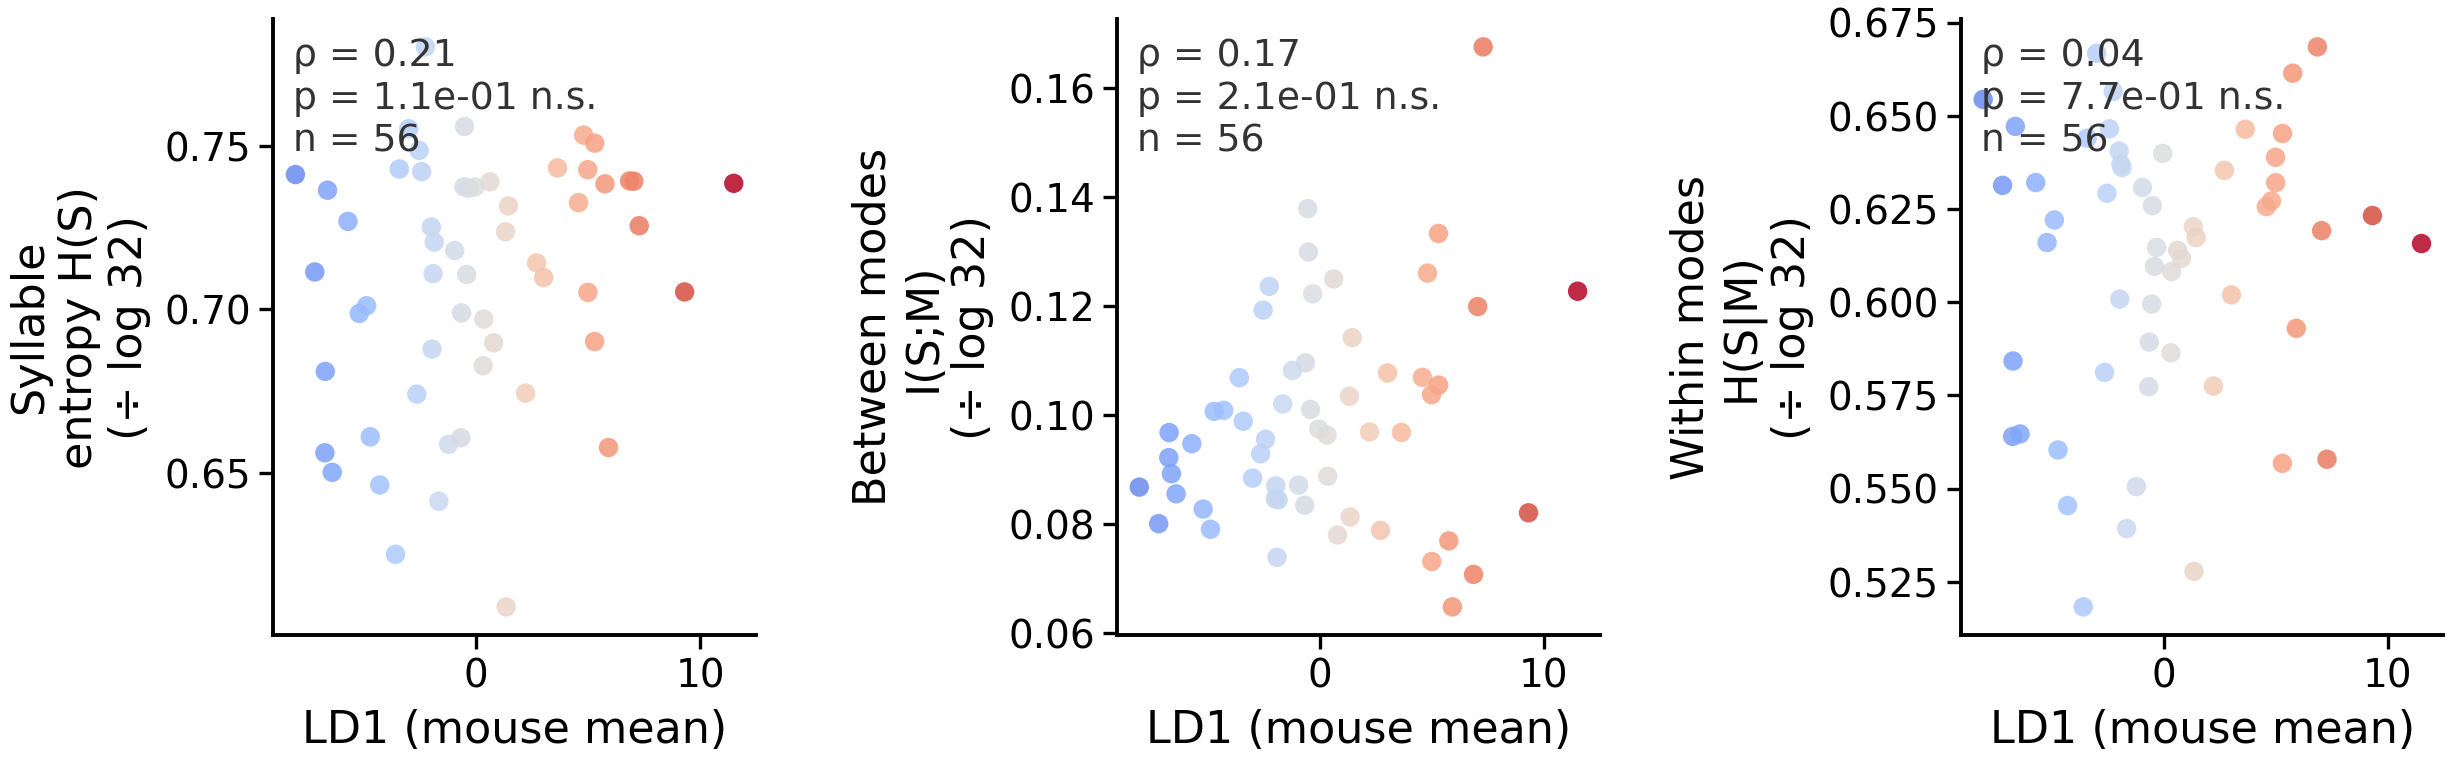

not saved (ps.SAVE_FIGURES is False): figures/fig_engagement_syllables_I_entropy_decomposition_07-10-2026.png, figures/fig_engagement_syllables_I_entropy_decomposition_07-10-2026.svg   -- ps.saving(True) to write, or pass save=True


[]

In [16]:
DEC_LABEL = {'H_syl': 'Syllable\nentropy H(S)', 'I_between': 'Between modes\nI(S;M)', 'H_within': 'Within modes\nH(S|M)'}
dm = to_mouse(dec, DEC_COLS)
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.0), gridspec_kw=dict(wspace=0.75))
for ax, c in zip(axes, DEC_LABEL):
    ps.corr_panel(ax, dm['lda_1'], dm[c], method='spearman', xlabel='LD1 (mouse mean)', ylabel=DEC_LABEL[c] + '\n(÷ log 32)')
plt.show()
ps.savefig(fig, f'{FIG}_I_entropy_decomposition', svg=True)

## The assembled figure (A–E, G)

One matplotlib figure at double-column width (180 mm), drawn by the same `draw_*` functions as the single panels above, so **every panel has the same type size** — nothing is scaled after drawing. Place it at 100% in the layout program.

Layout, top to bottom: A (state signature) full width; B (transitions) next to C (prediction); D (mode map) above G (entropy vs LD1) on the left, E (mode barcodes) on the right. Panel letters: set `LETTERS` to change them. B's syllable legend is left out (it is the same as A's).

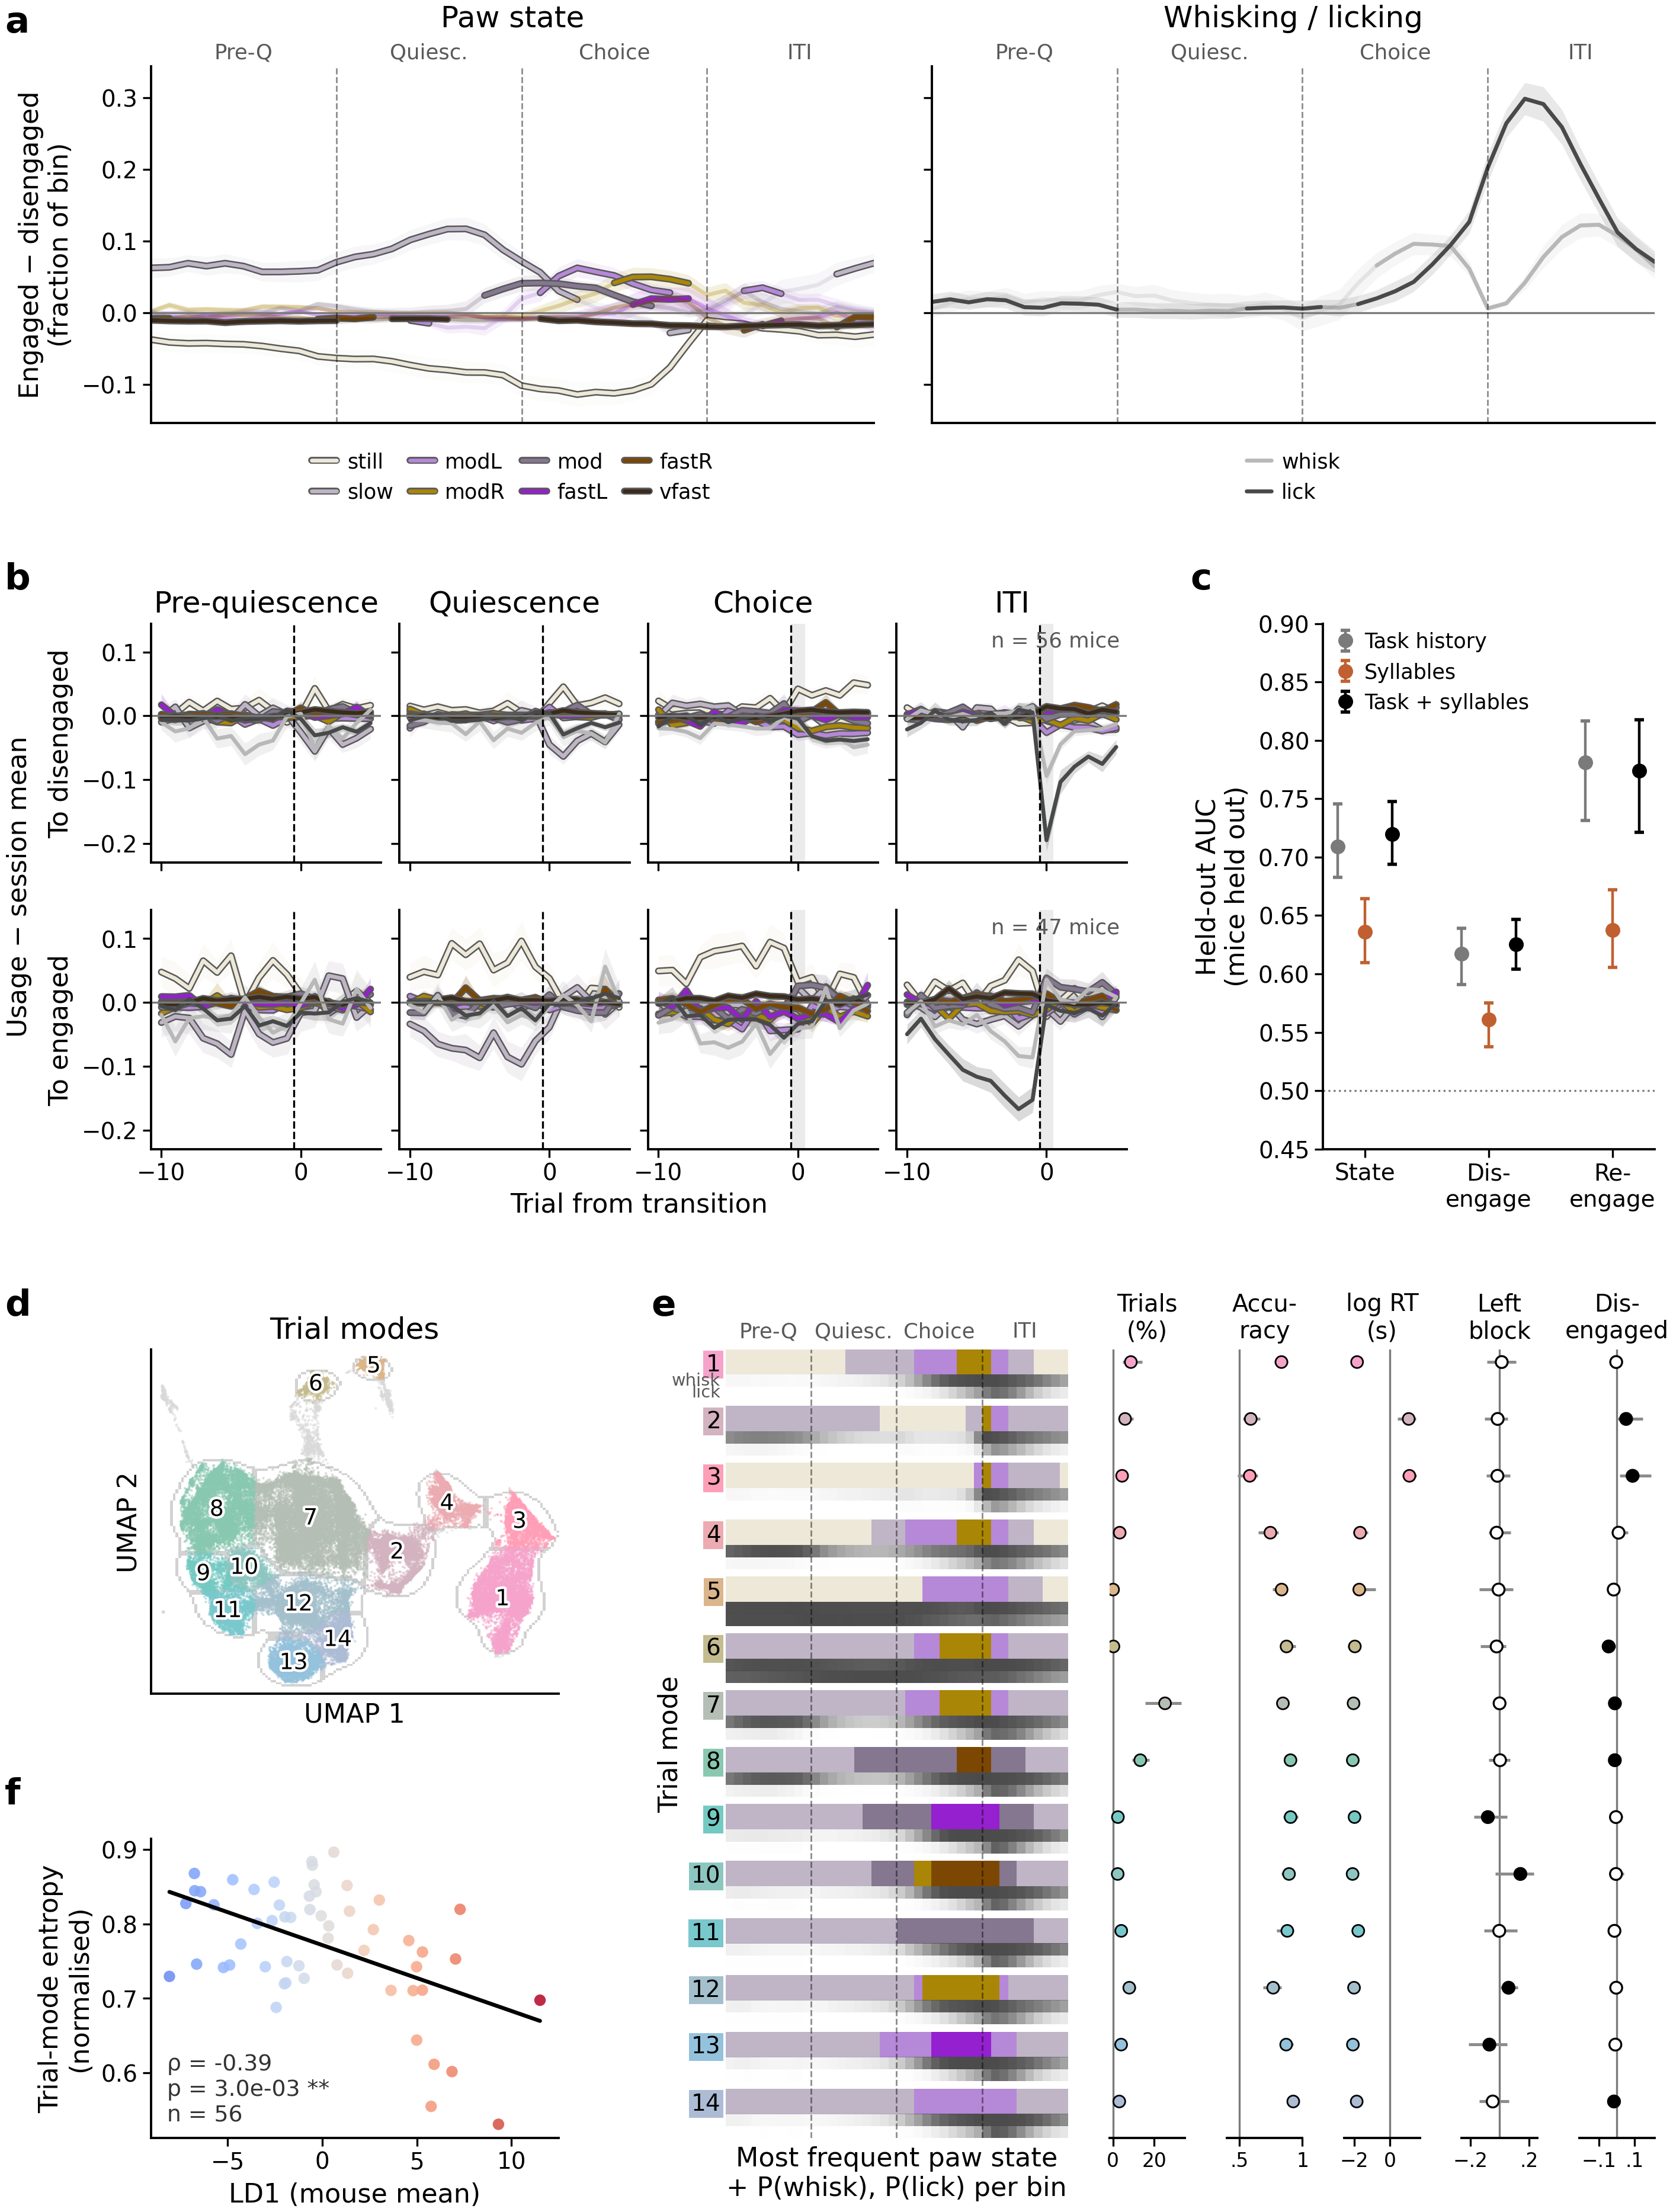

wrote figure_generation/figures/fig_engagement_syllables_assembled_07-10-2026.svg


wrote figure_generation/figures/fig_engagement_syllables.pdf


In [17]:
LETTERS = {'A': 'a', 'B': 'b', 'C': 'c', 'D': 'd', 'E': 'e', 'G': 'f'}
FIG_W, FIG_H = 7.09, 9.4                          # inches; 7.09 = 180 mm double column

def letter(fig, axes, key, x=None, dy=0.012):
    # bold panel letter at the top-left of the panel's outermost axes (labels included), or at a given x
    if x is None:
        x = max(min(a.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted()).x0
                    for a in axes) - 0.005, 0.003)
    y1 = max(a.get_position().y1 for a in axes)
    fig.text(x, y1 + dy, LETTERS[key], fontsize=plt.rcParams['font.size'] + 3,
             fontweight='bold', ha='left', va='bottom')

fig = plt.figure(figsize=(FIG_W, FIG_H))
outer = fig.add_gridspec(3, 1, height_ratios=[1.9, 2.8, 4.2], hspace=0.36,
                         left=0.09, right=0.985, top=0.965, bottom=0.035)
row2 = outer[1].subgridspec(1, 2, width_ratios=[5.0, 1.7], wspace=0.3)
row3 = outer[2].subgridspec(1, 2, width_ratios=[2.15, 4.9], wspace=0.25)
left3 = row3[0].subgridspec(2, 1, height_ratios=[1.15, 1], hspace=0.45)

panels = {'A': draw_A(fig, outer[0]),
          'B': draw_B(fig, row2[0], legend=False), 'C': draw_C(fig, row2[1]),
          'D': draw_D(fig, left3[0]), 'G': draw_G(fig, left3[1]), 'E': draw_E(fig, row3[1])}
# ALIGN THE LEFT COLUMN: the leftmost axes of a, c, d and f share one left edge (the rightmost of
# their current edges, so every y label still fits), and their letters share one x
LEFT_COLUMN = {'A': panels['A'][:1], 'B': [panels['B'][0], panels['B'][4]], 'D': panels['D'], 'G': panels['G']}
x_left = max(a.get_position().x0 for axs in LEFT_COLUMN.values() for a in axs)
for axs in LEFT_COLUMN.values():
    for a in axs:
        b = a.get_position()
        a.set_position([x_left, b.y0, b.x1 - x_left, b.height])
fig.canvas.draw()
r_ = fig.canvas.get_renderer()
x_letter = min(a.get_tightbbox(r_).transformed(fig.transFigure.inverted()).x0
               for axs in LEFT_COLUMN.values() for a in axs) - 0.005
for k, axes in panels.items():
    letter(fig, axes, k, x=max(x_letter, 0.003) if k in LEFT_COLUMN else None)
plt.show()
# the assembled figure is always written (SVG master, text kept as text) to figure_generation/figures/
from datetime import date
OUT_DIR = PI / 'figure_generation' / 'figures'
OUT_DIR.mkdir(exist_ok=True)
out = OUT_DIR / f"{FIG}_assembled_{date.today().strftime('%d-%m-%Y')}.svg"
fig.savefig(out, format='svg')
print('wrote', out.relative_to(PI))
# PDF for LaTeX/Overleaf (pdflatex cannot include SVG). Undated name, so the \includegraphics line never changes
pdf = OUT_DIR / f'{FIG}.pdf'
fig.savefig(pdf, format='pdf')
print('wrote', pdf.relative_to(PI))

## Numbers for the text

In [18]:
print('LD1 vs engagement axes (mouse level):')
print(rho_table(sess_eng, 'lda_1', ['switch_rate', 'frac_disengaged']).round(3), '\n')
print('LD1 vs entropies (mouse level):')
print(dec_res.round(3), '\n')
print('Prediction (pooled held-out AUC, log-loss skill):')
print(pred_res.pivot(index='setting', columns='model', values=['auc', 'll_skill']).round(3))

LD1 vs engagement axes (mouse level):
                 n_mice    rho      p  rho_lab_centred  p_lab_centred  rho_within  p_within
y                                                                                          
switch_rate          56 -0.347  0.009           -0.507          0.000       0.110     0.088
frac_disengaged      56  0.077  0.571            0.074          0.587      -0.026     0.687 

LD1 vs entropies (mouse level):
              n_mice    rho      p  rho_lab_centred  p_lab_centred  rho_within  p_within
y                                                                                       
H_syl             56  0.214  0.113            0.207          0.127       0.198     0.001
I_between         56  0.172  0.205            0.235          0.081       0.069     0.265
H_within          56  0.040  0.771            0.060          0.663       0.156     0.012
frac_between      56  0.109  0.425            0.180          0.185       0.027     0.662
H_modes           56 -0.38